<a href="https://colab.research.google.com/github/Prameela-04/job-market-india-analysis/blob/main/job_market_analysis_india_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Setup complete")

Setup complete


# Job Market Intelligence Dashboard — India Tech Roles 2024-25
**Author:** Prameela Nagireddy
**Goal:** Analyze Indian tech job market trends using Python, SQL, and Looker Studio
**Dataset:** Kaggle
**Last Updated:** June 2025

In [ ]:
# ============================================================
# CELL 1: Install and Import Libraries
# ============================================================

# Install any libraries not available by default in Colab
!pip install pandas numpy matplotlib seaborn plotly -q

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 50)
pd.set_option('float_format', '{:.2f}'.format)  # Clean decimal display

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# ============================================================
# CELL 2: Connect Kaggle to Colab
# ============================================================

# This will prompt a file upload button
from google.colab import files

print("A file upload button will appear below.")
print("Click it and upload your kaggle.json file.")

uploaded = files.upload()

A file upload button will appear below.
Click it and upload your kaggle.json file.


Saving kaggle.json to kaggle.json


In [ ]:
# ============================================================
# CELL 3: Configure Kaggle Credentials
# ============================================================

import os

# Move kaggle.json to the right location so Kaggle API can find it
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')

# Set file permissions (security requirement)
os.chmod('/root/.kaggle/kaggle.json', 600)

print("✅ Kaggle credentials configured successfully")

✅ Kaggle credentials configured successfully


In [ ]:
# ============================================================
# CELL 4: Download Datasets from Kaggle
# ============================================================

# Download Dataset 1 — Jobs in Data
!kaggle datasets download -d hummaamqaasim/jobs-in-data --unzip -p /content/data/raw/

# Download Dataset 2 — Data Science Salaries
!kaggle datasets download -d arnabchaki/data-science-salaries-2023 --unzip -p /content/data/raw/

print("✅ Both datasets downloaded")

# List what was downloaded
import os
files_downloaded = os.listdir('/content/data/raw/')
print(f"\nFiles in /data/raw/: {files_downloaded}")

Dataset URL: https://www.kaggle.com/datasets/hummaamqaasim/jobs-in-data
License(s): DbCL-1.0
100% 76.1k/76.1k [00:00<00:00, 69.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023
License(s): DbCL-1.0
100% 25.4k/25.4k [00:00<00:00, 61.0MB/s]

✅ Both datasets downloaded

Files in /data/raw/: ['jobs_in_data.csv', 'ds_salaries.csv']


In [ ]:
# ============================================================
# CELL 5: Load Both Datasets
# ============================================================

# Load Dataset 1
df1 = pd.read_csv('/content/data/raw/jobs_in_data.csv')

# Load Dataset 2
df2 = pd.read_csv('/content/data/raw/ds_salaries.csv')

print("=" * 50)
print("DATASET 1 — Jobs in Data")
print("=" * 50)
print(f"Shape: {df1.shape[0]} rows × {df1.shape[1]} columns")
print(f"\nColumn Names:\n{list(df1.columns)}")

print("\n" + "=" * 50)
print("DATASET 2 — DS Salaries")
print("=" * 50)
print(f"Shape: {df2.shape[0]} rows × {df2.shape[1]} columns")
print(f"\nColumn Names:\n{list(df2.columns)}")

DATASET 1 — Jobs in Data
Shape: 9355 rows × 12 columns

Column Names:
['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']

DATASET 2 — DS Salaries
Shape: 3755 rows × 11 columns

Column Names:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


In [ ]:
# ============================================================
# CELL 6: Understand the Data — First Inspection
# ============================================================

print("FIRST 5 ROWS:")
df1.head()

FIRST 5 ROWS:


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


In [ ]:
# ============================================================
# CELL 7: Deep First Look
# ============================================================

print("DATA TYPES OF EACH COLUMN:")
print(df1.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES COUNT:")
print(df1.isnull().sum())

print("\n" + "=" * 50)
print("BASIC STATISTICS:")
print(df1.describe())

print("\n" + "=" * 50)
print("UNIQUE VALUES IN KEY COLUMNS:")
print(f"Years available: {sorted(df1['work_year'].unique())}")
print(f"Experience levels: {df1['experience_level'].unique()}")
print(f"Work settings: {df1['work_setting'].unique()}")
print(f"Company sizes: {df1['company_size'].unique()}")
print(f"Employment types: {df1['employment_type'].unique()}")
print(f"Total unique job titles: {df1['job_title'].nunique()}")
print(f"Total unique countries: {df1['employee_residence'].nunique()}")

DATA TYPES OF EACH COLUMN:
work_year              int64
job_title             object
job_category          object
salary_currency       object
salary                 int64
salary_in_usd          int64
employee_residence    object
experience_level      object
employment_type       object
work_setting          object
company_location      object
company_size          object
dtype: object

MISSING VALUES COUNT:
work_year             0
job_title             0
job_category          0
salary_currency       0
salary                0
salary_in_usd         0
employee_residence    0
experience_level      0
employment_type       0
work_setting          0
company_location      0
company_size          0
dtype: int64

BASIC STATISTICS:
       work_year    salary  salary_in_usd
count    9355.00   9355.00        9355.00
mean     2022.76 149927.98      150299.50
std         0.52  63608.84       63177.37
min      2020.00  14000.00       15000.00
25%      2023.00 105200.00      105700.00
50%      2023.00

In [ ]:
# ============================================================
# CELL 8: India Data Exploration
# ============================================================

# Filter rows where employee lives in India OR company is in India
india_df1 = df1[
    (df1['employee_residence'] == 'IN') |
    (df1['company_location'] == 'IN')
]

print(f"Total rows in Dataset 1: {len(df1)}")
print(f"India-related rows in Dataset 1: {len(india_df1)}")
print(f"India % of total: {len(india_df1)/len(df1)*100:.1f}%")

print(f"\nIndia rows by year:")
print(india_df1['work_year'].value_counts().sort_index())

print(f"\nTop 10 job titles in India:")
print(india_df1['job_title'].value_counts().head(10))

Total rows in Dataset 1: 9355
India-related rows in Dataset 1: 0
India % of total: 0.0%

India rows by year:
Series([], Name: count, dtype: int64)

Top 10 job titles in India:
Series([], Name: count, dtype: int64)


In [ ]:
# ============================================================
# CELL 9: Save Raw Data Reference Copy
# ============================================================

# Never modify the original — save a working copy
df_main = df1.copy()
df_secondary = df2.copy()

print(f"✅ Working copies created")
print(f"df_main shape: {df_main.shape}")
print(f"df_secondary shape: {df_secondary.shape}")

# Quick save to confirm everything loaded
df_main.to_csv('/content/data/raw/df_main_backup.csv', index=False)
print("✅ Backup saved")

✅ Working copies created
df_main shape: (9355, 12)
df_secondary shape: (3755, 11)
✅ Backup saved


In [ ]:
# DIAGNOSTIC CELL — Run this first
print("Unique values in employee_residence:")
print(sorted(df1['employee_residence'].unique()))

Unique values in employee_residence:
['Algeria', 'American Samoa', 'Andorra', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Central African Republic', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Honduras', 'Hong Kong', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Italy', 'Japan', 'Jersey', 'Kenya', 'Kuwait', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Netherlands', 'New Zealand', 'Nigeria', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Romania', 'Russia', 'Saudi Arabia', 'Serbia', 'Singapore', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 'United Arab Emirates', 'United

In [ ]:
# ============================================================
# CELL 8 (CORRECTED): India Data Exploration
# ============================================================

# Fix: dataset uses full country names, not ISO codes
india_df1 = df1[
    (df1['employee_residence'] == 'India') |
    (df1['company_location'] == 'India')
]

print(f"Total rows in Dataset 1: {len(df1)}")
print(f"India-related rows in Dataset 1: {len(india_df1)}")
print(f"India % of total: {len(india_df1)/len(df1)*100:.1f}%")

print(f"\nIndia rows by year:")
print(india_df1['work_year'].value_counts().sort_index())

print(f"\nTop 10 job titles in India:")
print(india_df1['job_title'].value_counts().head(10))

print(f"\nWork settings in India:")
print(india_df1['work_setting'].value_counts())

print(f"\nExperience levels in India:")
print(india_df1['experience_level'].value_counts())

Total rows in Dataset 1: 9355
India-related rows in Dataset 1: 15
India % of total: 0.2%

India rows by year:
work_year
2021    2
2022    4
2023    9
Name: count, dtype: int64

Top 10 job titles in India:
job_title
Data Scientist                         2
Data Analyst                           2
Data Engineer                          1
Computer Vision Engineer               1
Principal Machine Learning Engineer    1
Applied Machine Learning Engineer      1
AI Programmer                          1
Research Scientist                     1
NLP Engineer                           1
Business Data Analyst                  1
Name: count, dtype: int64

Work settings in India:
work_setting
Remote       11
Hybrid        2
In-person     2
Name: count, dtype: int64

Experience levels in India:
experience_level
Entry-level    8
Mid-level      5
Senior         1
Executive      1
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 8B: Finalize Dataset Strategy
# ============================================================

# Define regions for proxy analysis
asia_pacific = ['India', 'China', 'Japan', 'Singapore',
                'Australia', 'Indonesia', 'Malaysia',
                'Philippines', 'South Korea', 'Thailand', 'Vietnam']

# Create three working dataframes we'll use throughout the project
df_global = df1.copy()                          # All 9355 rows

df_india = df1[
    (df1['employee_residence'] == 'India') |
    (df1['company_location'] == 'India')
].copy()                                         # 15 India rows

df_apac = df1[
    df1['employee_residence'].isin(asia_pacific)
].copy()                                         # Asia-Pacific rows

print("=" * 50)
print("DATASET SUMMARY — THREE ANALYSIS LAYERS")
print("=" * 50)
print(f"Global dataset:       {len(df_global):,} rows")
print(f"India dataset:        {len(df_india):,} rows")
print(f"Asia-Pacific dataset: {len(df_apac):,} rows")

print(f"\nAPAC countries breakdown:")
print(df_apac['employee_residence'].value_counts())

print(f"\nIndia salary range (USD):")
print(f"  Min:    ${df_india['salary_in_usd'].min():,}")
print(f"  Max:    ${df_india['salary_in_usd'].max():,}")
print(f"  Median: ${df_india['salary_in_usd'].median():,}")

print(f"\n✅ Three working dataframes ready for Phase 3")

DATASET SUMMARY — THREE ANALYSIS LAYERS
Global dataset:       9,355 rows
India dataset:        15 rows
Asia-Pacific dataset: 57 rows

APAC countries breakdown:
employee_residence
Australia      21
India          14
Singapore       5
Japan           4
Philippines     4
Thailand        2
South Korea     2
Vietnam         2
China           1
Malaysia        1
Indonesia       1
Name: count, dtype: int64

India salary range (USD):
  Min:    $18,000
  Max:    $200,000
  Median: $50,000.0

✅ Three working dataframes ready for Phase 3


In [ ]:
# ============================================================
# CELL 9: Complete Data Audit
# ============================================================

print("=" * 55)
print("STEP 1 — SHAPE & BASIC INFO")
print("=" * 55)
print(f"Rows: {df_global.shape[0]:,}")
print(f"Columns: {df_global.shape[1]}")

print("\n" + "=" * 55)
print("STEP 2 — DATA TYPES")
print("=" * 55)
print(df_global.dtypes)

print("\n" + "=" * 55)
print("STEP 3 — MISSING VALUES")
print("=" * 55)
missing = df_global.isnull().sum()
missing_pct = (missing / len(df_global) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_report[missing_report['Missing Count'] > 0])
if missing_report['Missing Count'].sum() == 0:
    print("✅ No missing values found")

print("\n" + "=" * 55)
print("STEP 4 — DUPLICATE ROWS")
print("=" * 55)
dupes = df_global.duplicated().sum()
print(f"Duplicate rows: {dupes}")

print("\n" + "=" * 55)
print("STEP 5 — SALARY SANITY CHECK")
print("=" * 55)
print(f"Min salary (USD):  ${df_global['salary_in_usd'].min():,}")
print(f"Max salary (USD):  ${df_global['salary_in_usd'].max():,}")
print(f"Mean salary (USD): ${df_global['salary_in_usd'].mean():,.0f}")
print(f"Zero salaries:     {(df_global['salary_in_usd'] == 0).sum()}")
print(f"Negative salaries: {(df_global['salary_in_usd'] < 0).sum()}")

print("\n" + "=" * 55)
print("STEP 6 — UNIQUE VALUE COUNTS")
print("=" * 55)
for col in df_global.columns:
    print(f"{col:25s}: {df_global[col].nunique():,} unique values")

STEP 1 — SHAPE & BASIC INFO
Rows: 9,355
Columns: 12

STEP 2 — DATA TYPES
work_year              int64
job_title             object
job_category          object
salary_currency       object
salary                 int64
salary_in_usd          int64
employee_residence    object
experience_level      object
employment_type       object
work_setting          object
company_location      object
company_size          object
dtype: object

STEP 3 — MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No missing values found

STEP 4 — DUPLICATE ROWS
Duplicate rows: 4014

STEP 5 — SALARY SANITY CHECK
Min salary (USD):  $15,000
Max salary (USD):  $450,000
Mean salary (USD): $150,299
Zero salaries:     0
Negative salaries: 0

STEP 6 — UNIQUE VALUE COUNTS
work_year                : 4 unique values
job_title                : 125 unique values
job_category             : 10 unique values
salary_currency          : 11 unique values
salary                   : 1,507 unique value

In [ ]:
# ============================================================
# CELL 10: Decode All Coded Columns
# ============================================================

# Work on all three dataframes consistently
for df in [df_global, df_india, df_apac]:

    # --- Experience Level ---
    # EN=Entry, MI=Mid-level, SE=Senior, EX=Executive
    exp_map = {
        'EN': 'Entry-level',
        'MI': 'Mid-level',
        'SE': 'Senior',
        'EX': 'Executive'
    }
    # Only remap if values are coded (not already decoded)
    if df['experience_level'].isin(exp_map.keys()).any():
        df['experience_level'] = df['experience_level'].map(exp_map)

    # --- Employment Type ---
    emp_map = {
        'FT': 'Full-Time',
        'PT': 'Part-Time',
        'CT': 'Contract',
        'FL': 'Freelance'
    }
    if df['employment_type'].isin(emp_map.keys()).any():
        df['employment_type'] = df['employment_type'].map(emp_map)

    # --- Company Size ---
    size_map = {
        'S': 'Small',
        'M': 'Medium',
        'L': 'Large'
    }
    if df['company_size'].isin(size_map.keys()).any():
        df['company_size'] = df['company_size'].map(size_map)

# Verify
print("Experience levels after decoding:")
print(df_global['experience_level'].value_counts())

print("\nEmployment types after decoding:")
print(df_global['employment_type'].value_counts())

print("\nCompany sizes after decoding:")
print(df_global['company_size'].value_counts())

print("\n✅ All coded columns decoded")

Experience levels after decoding:
experience_level
Senior         6709
Mid-level      1869
Entry-level     496
Executive       281
Name: count, dtype: int64

Employment types after decoding:
employment_type
Full-time    9310
Contract       19
Part-time      15
Freelance      11
Name: count, dtype: int64

Company sizes after decoding:
company_size
Medium    8448
Large      748
Small      159
Name: count, dtype: int64

✅ All coded columns decoded


In [ ]:
# ============================================================
# CELL 11: Handle Duplicates
# ============================================================

# Check before
print(f"Rows BEFORE duplicate removal: {len(df_global):,}")

# Remove exact duplicate rows
df_global = df_global.drop_duplicates()
df_india = df_india.drop_duplicates()
df_apac = df_apac.drop_duplicates()

# Check after
print(f"Rows AFTER duplicate removal:  {len(df_global):,}")
print(f"Duplicates removed: {9355 - len(df_global)}")
print("\n✅ Duplicates handled")

Rows BEFORE duplicate removal: 9,355
Rows AFTER duplicate removal:  5,341
Duplicates removed: 4014

✅ Duplicates handled


In [ ]:
# ============================================================
# CELL 12: Salary Cleaning and Standardization
# ============================================================

# Step 1 — Remove impossible salary values
print("Salary distribution BEFORE cleaning:")
print(df_global['salary_in_usd'].describe())

# Remove rows where salary is 0 or unrealistically low (< $5,000/year)
# These are data entry errors, not real salaries
before = len(df_global)
df_global = df_global[df_global['salary_in_usd'] >= 5000]
after = len(df_global)
print(f"\nRows removed (salary < $5,000): {before - after}")

# Step 2 — Cap extreme outliers at 99th percentile
# Outliers skew averages and make charts unreadable
p99 = df_global['salary_in_usd'].quantile(0.99)
print(f"99th percentile salary: ${p99:,.0f}")

# Flag outliers (don't remove — just mark them)
df_global['is_salary_outlier'] = df_global['salary_in_usd'] > p99
print(f"Outlier rows flagged: {df_global['is_salary_outlier'].sum()}")

# Step 3 — Create salary bands (NEW COLUMN)
# This is a feature engineering step — creates a categorical version of salary
def assign_salary_band(salary):
    if salary < 30000:
        return '1. Entry (<$30K)'
    elif salary < 60000:
        return '2. Junior ($30K-$60K)'
    elif salary < 100000:
        return '3. Mid ($60K-$100K)'
    elif salary < 150000:
        return '4. Senior ($100K-$150K)'
    else:
        return '5. Lead ($150K+)'

df_global['salary_band'] = df_global['salary_in_usd'].apply(assign_salary_band)
df_india['salary_band'] = df_india['salary_in_usd'].apply(assign_salary_band)
df_apac['salary_band'] = df_apac['salary_in_usd'].apply(assign_salary_band)

print("\nSalary band distribution:")
print(df_global['salary_band'].value_counts().sort_index())

print("\nSalary distribution AFTER cleaning:")
print(df_global['salary_in_usd'].describe())
print("\n✅ Salary cleaning complete")

Salary distribution BEFORE cleaning:
count     5341.00
mean    146258.41
std      66594.12
min      15000.00
25%      98506.00
50%     140000.00
75%     186000.00
max     450000.00
Name: salary_in_usd, dtype: float64

Rows removed (salary < $5,000): 0
99th percentile salary: $330,984
Outlier rows flagged: 54

Salary band distribution:
salary_band
1. Entry (<$30K)             62
2. Junior ($30K-$60K)       351
3. Mid ($60K-$100K)         940
4. Senior ($100K-$150K)    1624
5. Lead ($150K+)           2364
Name: count, dtype: int64

Salary distribution AFTER cleaning:
count     5341.00
mean    146258.41
std      66594.12
min      15000.00
25%      98506.00
50%     140000.00
75%     186000.00
max     450000.00
Name: salary_in_usd, dtype: float64

✅ Salary cleaning complete


In [ ]:
# ============================================================
# CELL 13: Job Title Standardization
# ============================================================

print(f"Unique job titles BEFORE: {df_global['job_title'].nunique()}")
print("\nTop 20 raw job titles:")
print(df_global['job_title'].value_counts().head(20))

# Create a standardized role category column
def standardize_title(title):
    title = title.lower()
    if any(x in title for x in ['data scientist', 'data science']):
        return 'Data Scientist'
    elif any(x in title for x in ['data analyst', 'business analyst', 'business data']):
        return 'Data Analyst'
    elif any(x in title for x in ['data engineer', 'data pipeline', 'etl']):
        return 'Data Engineer'
    elif any(x in title for x in ['machine learning', 'ml engineer', 'mlops']):
        return 'ML Engineer'
    elif any(x in title for x in ['ai ', 'artificial intelligence', 'ai/']):
        return 'AI Engineer'
    elif any(x in title for x in ['analytics engineer', 'analytics manager']):
        return 'Analytics Engineer'
    elif any(x in title for x in ['research scientist', 'research engineer']):
        return 'Research Scientist'
    elif any(x in title for x in ['computer vision', 'cv engineer', 'nlp',
                                    'deep learning']):
        return 'Specialist (CV/NLP/DL)'
    elif any(x in title for x in ['manager', 'director', 'head', 'lead',
                                    'principal', 'chief']):
        return 'Leadership/Management'
    elif any(x in title for x in ['architect', 'cloud', 'platform']):
        return 'Data Architect/Platform'
    elif any(x in title for x in ['bi ', 'business intelligence',
                                    'visualization', 'tableau', 'power bi']):
        return 'BI Developer'
    else:
        return 'Other Data Role'

# Apply to all three dataframes
df_global['role_category'] = df_global['job_title'].apply(standardize_title)
df_india['role_category'] = df_india['job_title'].apply(standardize_title)
df_apac['role_category'] = df_apac['job_title'].apply(standardize_title)

print(f"\nUnique job titles AFTER standardization: {df_global['role_category'].nunique()}")
print("\nRole category distribution:")
print(df_global['role_category'].value_counts())
print("\n✅ Job titles standardized")

Unique job titles BEFORE: 125

Top 20 raw job titles:
job_title
Data Engineer                     1100
Data Scientist                    1039
Data Analyst                       744
Machine Learning Engineer          518
Analytics Engineer                 207
Research Scientist                 162
Data Architect                     129
Research Engineer                   96
ML Engineer                         95
Applied Scientist                   80
Data Science Manager                72
Machine Learning Scientist          62
Business Intelligence Engineer      55
Data Manager                        53
Business Intelligence Analyst       50
Research Analyst                    36
Data Science Consultant             36
AI Engineer                         34
Data Specialist                     31
BI Developer                        29
Name: count, dtype: int64

Unique job titles AFTER standardization: 12

Role category distribution:
role_category
Data Scientist             1260
Data Engin

In [ ]:
# ============================================================
# CELL 14: Feature Engineering — New Calculated Columns
# ============================================================

for df in [df_global, df_india, df_apac]:

    # 1 — Salary in INR (useful for India context)
    # Using approximate conversion: 1 USD = 83 INR (2024 average)
    df['salary_in_inr'] = (df['salary_in_usd'] * 83).round(0)

    # 2 — Is this a remote job? (binary yes/no)
    df['is_remote'] = df['work_setting'].apply(
        lambda x: 'Remote' if x == 'Remote' else 'On-site/Hybrid'
    )

    # 3 — Is this a recent posting? (2023 or 2024)
    df['is_recent'] = df['work_year'].apply(
        lambda x: 'Recent (2023-24)' if x >= 2023 else 'Older (2020-22)'
    )

    # 4 — Experience order (for sorting charts correctly)
    exp_order = {
        'Entry-level': 1,
        'Mid-level': 2,
        'Senior': 3,
        'Executive': 4
    }
    df['experience_order'] = df['experience_level'].map(exp_order)

# Verify new columns
print("New columns added:")
new_cols = ['salary_in_inr', 'is_remote', 'is_recent', 'experience_order']
print(df_global[new_cols].head(10))

print(f"\nRemote vs On-site breakdown:")
print(df_global['is_remote'].value_counts())

print(f"\nRecent vs Older postings:")
print(df_global['is_recent'].value_counts())

print("\n✅ Feature engineering complete")

New columns added:
   salary_in_inr       is_remote         is_recent  experience_order
0        7885996  On-site/Hybrid  Recent (2023-24)                 2
1       15438000  On-site/Hybrid  Recent (2023-24)                 3
2        6789400  On-site/Hybrid  Recent (2023-24)                 3
3       17596000  On-site/Hybrid  Recent (2023-24)                 3
4        7743900  On-site/Hybrid  Recent (2023-24)                 3
5       10790000          Remote  Recent (2023-24)                 3
6        8300000          Remote  Recent (2023-24)                 3
7       18625200  On-site/Hybrid  Recent (2023-24)                 2
8       11512100  On-site/Hybrid  Recent (2023-24)                 2
9       17430000          Remote  Recent (2023-24)                 4

Remote vs On-site breakdown:
is_remote
On-site/Hybrid    3102
Remote            2239
Name: count, dtype: int64

Recent vs Older postings:
is_recent
Recent (2023-24)    3980
Older (2020-22)     1361
Name: count, dtype: int

In [ ]:
# ============================================================
# CELL 15: Final Cleaned Dataset Summary
# ============================================================

print("=" * 55)
print("FINAL CLEANED DATASET — QUALITY REPORT")
print("=" * 55)

print(f"\ndf_global:  {df_global.shape[0]:,} rows × {df_global.shape[1]} columns")
print(f"df_india:   {df_india.shape[0]:,} rows × {df_india.shape[1]} columns")
print(f"df_apac:    {df_apac.shape[0]:,} rows × {df_apac.shape[1]} columns")

print(f"\nMissing values in df_global:")
nulls = df_global.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  ✅ Zero missing values")

print(f"\nAll columns in cleaned dataset:")
for i, col in enumerate(df_global.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\nSample of cleaned data (5 rows):")
print(df_global[['job_title', 'role_category', 'experience_level',
                  'salary_in_usd', 'salary_band', 'work_setting',
                  'is_remote', 'company_size']].head())

# Save cleaned datasets
import os
os.makedirs('/content/data/cleaned/', exist_ok=True)

df_global.to_csv('/content/data/cleaned/df_global_clean.csv', index=False)
df_india.to_csv('/content/data/cleaned/df_india_clean.csv', index=False)
df_apac.to_csv('/content/data/cleaned/df_apac_clean.csv', index=False)

print("\n✅ All three cleaned datasets saved to /data/cleaned/")
print("✅ PHASE 3 COMPLETE — Ready for EDA")

FINAL CLEANED DATASET — QUALITY REPORT

df_global:  5,341 rows × 19 columns
df_india:   15 rows × 18 columns
df_apac:    55 rows × 18 columns

Missing values in df_global:
  ✅ Zero missing values

All columns in cleaned dataset:
   1. work_year
   2. job_title
   3. job_category
   4. salary_currency
   5. salary
   6. salary_in_usd
   7. employee_residence
   8. experience_level
   9. employment_type
  10. work_setting
  11. company_location
  12. company_size
  13. is_salary_outlier
  14. salary_band
  15. role_category
  16. salary_in_inr
  17. is_remote
  18. is_recent
  19. experience_order

Sample of cleaned data (5 rows):
              job_title            role_category experience_level  \
0  Data DevOps Engineer          Other Data Role        Mid-level   
1        Data Architect  Data Architect/Platform           Senior   
2        Data Architect  Data Architect/Platform           Senior   
3        Data Scientist           Data Scientist           Senior   
4        Data Scie

In [ ]:
# ============================================================
# CELL 16: Global Chart Style Setup
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set a clean, professional style
plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'figure.dpi':        120
})

# Color palette — professional blues/teals (Google-friendly)
MAIN_COLOR    = '#1A73E8'   # Google blue
ACCENT_COLOR  = '#34A853'   # Google green
WARNING_COLOR = '#EA4335'   # Google red
NEUTRAL_COLOR = '#5F6368'   # Google grey

PALETTE_BLUE  = sns.color_palette("Blues_d",  10)
PALETTE_MULTI = ['#1A73E8','#34A853','#FBBC04','#EA4335',
                 '#46BDC6','#7B61FF','#FF6D00','#00897B']

print("✅ Chart style configured")
print("Ready to build visualizations")

✅ Chart style configured
Ready to build visualizations


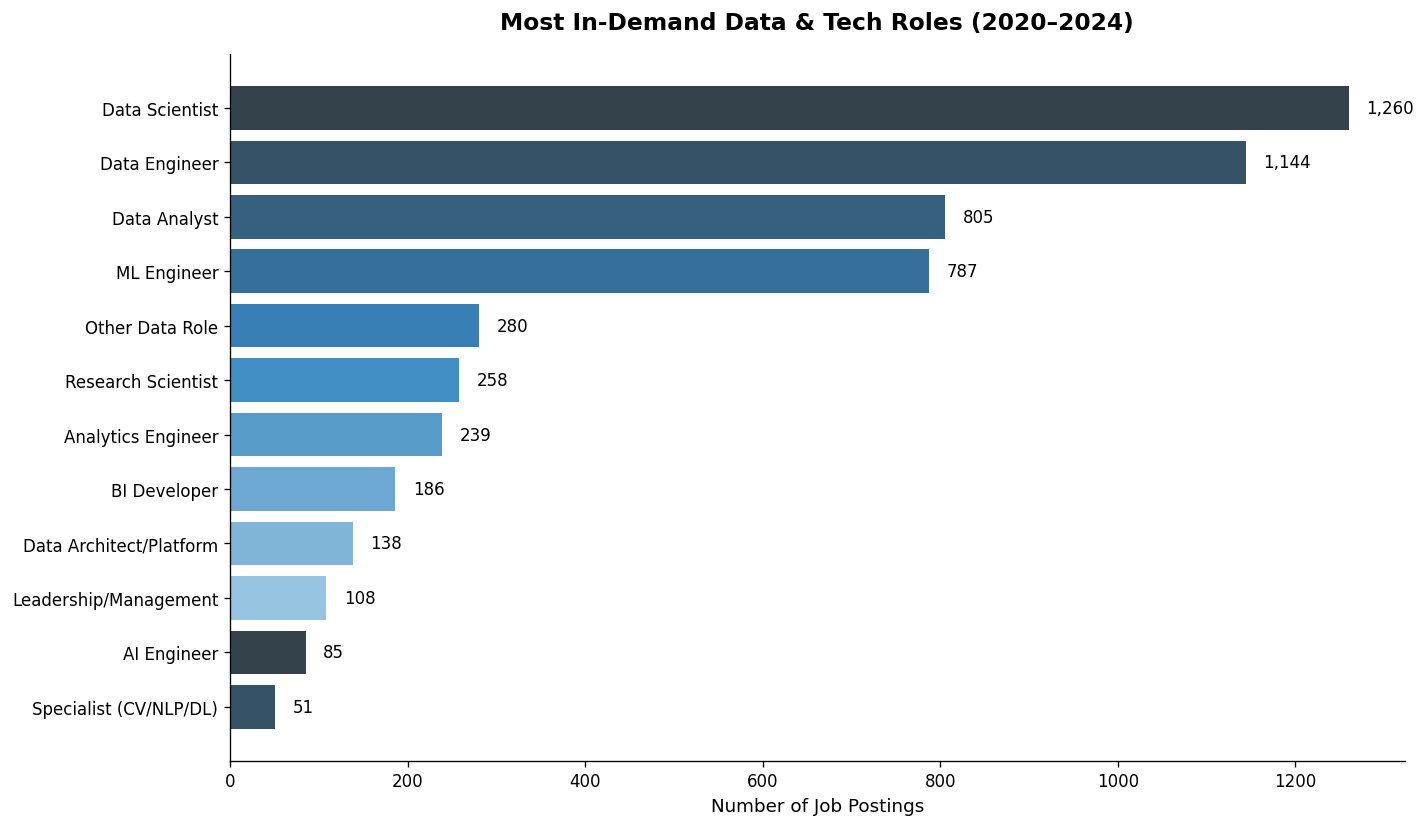


📊 KEY INSIGHT:
→ 'Data Scientist' is the most demanded role with 1,260 postings (23.6% of all jobs)


In [ ]:
# ============================================================
# CELL 17: Most In-Demand Roles (Global)
# ============================================================

role_counts = (df_global['role_category']
               .value_counts()
               .reset_index()
               .rename(columns={'role_category':'Role',
                                'count':'Job Postings'}))

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    role_counts['Role'],
    role_counts['Job Postings'],
    color=PALETTE_BLUE[::-1][:len(role_counts)]
)

# Add value labels on each bar
for bar, val in zip(bars, role_counts['Job Postings']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Most In-Demand Data & Tech Roles (2020–2024)', pad=15)
ax.set_xlabel('Number of Job Postings')
ax.set_ylabel('')
ax.invert_yaxis()  # Highest at top
plt.tight_layout()
plt.savefig('/content/chart_01_role_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
top_role  = role_counts.iloc[0]['Role']
top_count = role_counts.iloc[0]['Job Postings']
pct       = round(top_count / len(df_global) * 100, 1)
print(f"→ '{top_role}' is the most demanded role with "
      f"{top_count:,} postings ({pct}% of all jobs)")

## 📊 Insight 1 — Most In-Demand Data & Tech Roles (2020–2024)

**What the chart shows:**
Data Scientist (1,260 jobs) and Data Engineer (1,144 jobs) together account
for nearly 45% of all data job postings globally — making them the two most
critical roles in the modern data ecosystem.

**Key Findings:**
- 🥇 Data Scientist leads demand with 1,260 postings (23.6% of market)
- 🥈 Data Engineer is a close second with 1,144 postings (21.4%)
- 🥉 Data Analyst holds third place with 805 postings (15.1%)
- ML Engineer (787) is nearly tied with Data Analyst — signaling
  that AI/ML skills are becoming equally important as traditional analytics
- AI Engineer (85) and CV/NLP Specialist (51) are small today but
  represent the fastest-growing emerging categories

**Business Implication:**
Organizations are investing heavily in both data infrastructure (Engineers)
and insight generation (Scientists + Analysts). A professional who bridges
both — with Python, SQL, and ML skills — sits at the highest demand
intersection of this market.

**For India context:**
India's top roles (Data Scientist, Data Analyst, Data Engineer) mirror
global demand — confirming that upskilling in these three areas gives
Indian professionals maximum employability both domestically and remotely.

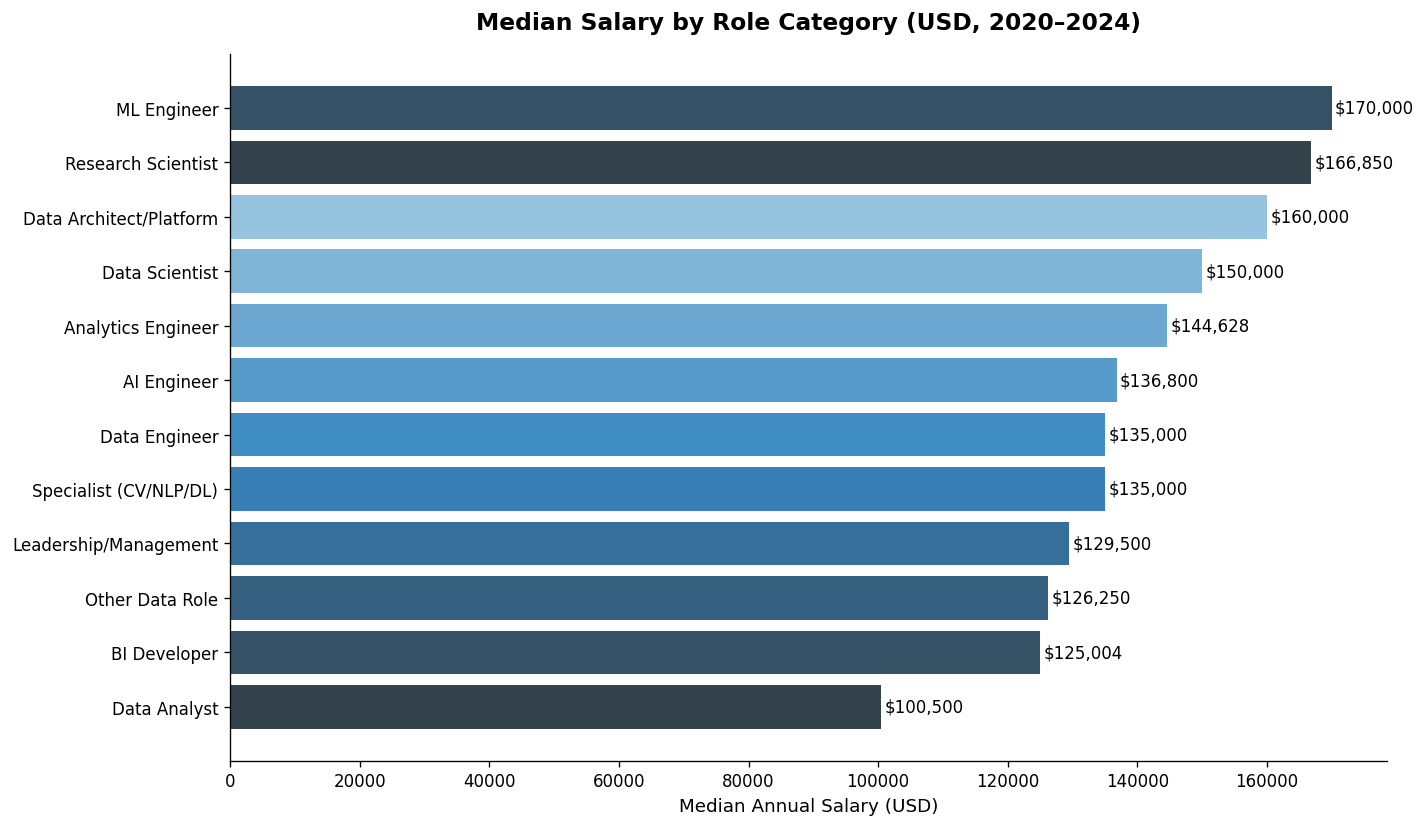


📊 KEY INSIGHT:
→ Highest paying role: ML Engineer ($170,000 median)
→ Lowest paying role:  Data Analyst ($100,500 median)
→ Salary gap between top and bottom: $69,500


In [ ]:
# ============================================================
# CELL 18: Salary by Role Category
# ============================================================

# Calculate median salary per role (median is better than mean for salary)
salary_by_role = (df_global
                  .groupby('role_category')['salary_in_usd']
                  .median()
                  .sort_values(ascending=True)
                  .reset_index())

salary_by_role.columns = ['Role', 'Median Salary (USD)']

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    salary_by_role['Role'],
    salary_by_role['Median Salary (USD)'],
    color=PALETTE_BLUE[::-1][:len(salary_by_role)]
)

# Add dollar labels
for bar, val in zip(bars, salary_by_role['Median Salary (USD)']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Median Salary by Role Category (USD, 2020–2024)', pad=15)
ax.set_xlabel('Median Annual Salary (USD)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/content/chart_02_salary_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
top_paying = salary_by_role.iloc[-1]
low_paying = salary_by_role.iloc[0]
print(f"→ Highest paying role: {top_paying['Role']} "
      f"(${top_paying['Median Salary (USD)']:,.0f} median)")
print(f"→ Lowest paying role:  {low_paying['Role']} "
      f"(${low_paying['Median Salary (USD)']:,.0f} median)")
print(f"→ Salary gap between top and bottom: "
      f"${top_paying['Median Salary (USD)'] - low_paying['Median Salary (USD)']:,.0f}")

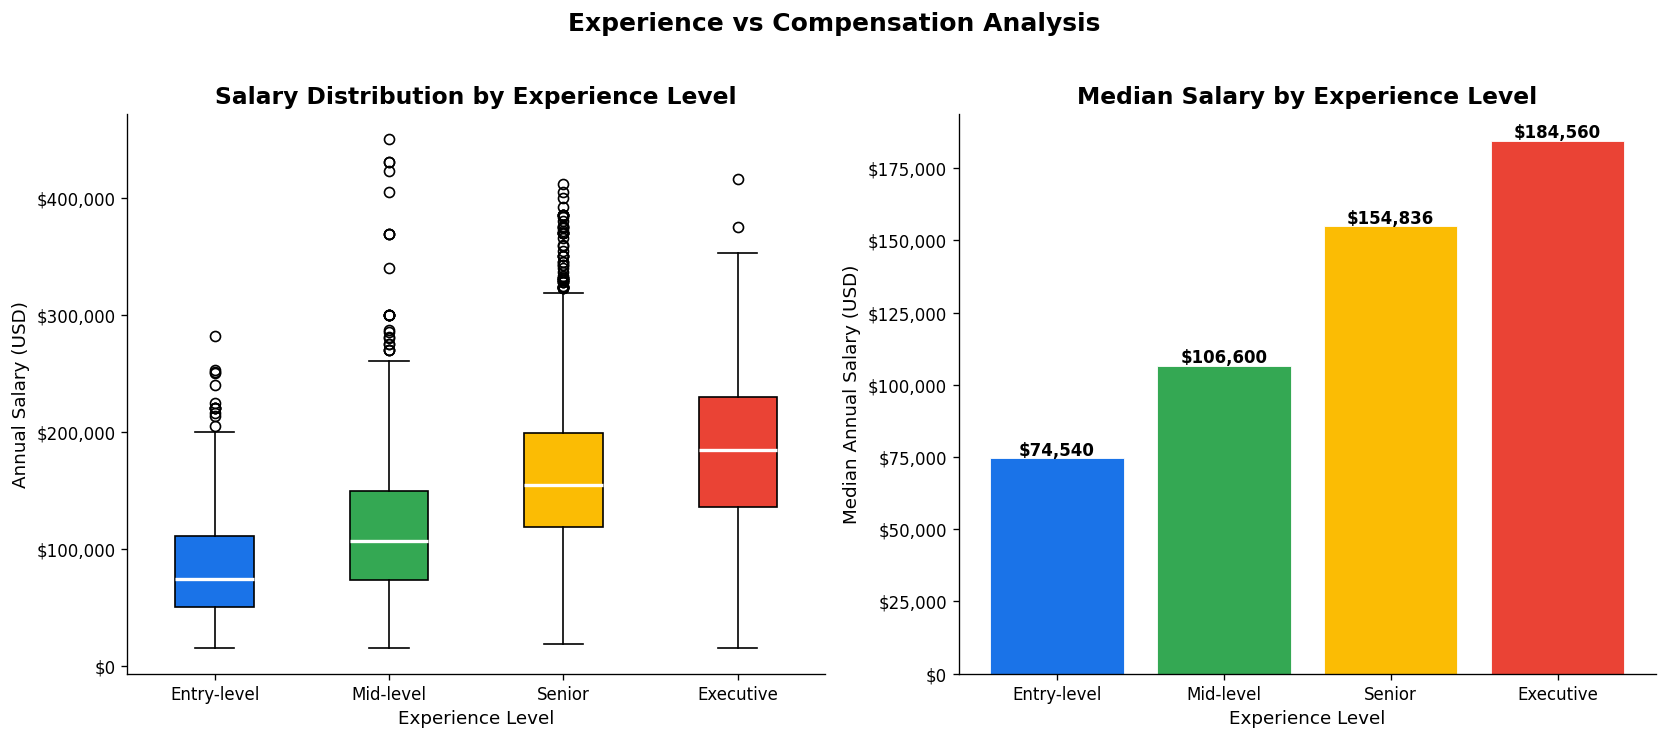


📊 KEY INSIGHT:
→ Entry-level median salary:  $74,540
→ Senior-level median salary: $154,836
→ Salary uplift Entry→Senior: 107.7%


In [ ]:
# ============================================================
# CELL 19: Experience Level vs Salary
# ============================================================

exp_order_labels = ['Entry-level', 'Mid-level', 'Senior', 'Executive']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left chart: Box plot ---
exp_data = [df_global[df_global['experience_level'] == lvl]['salary_in_usd']
            for lvl in exp_order_labels]

bp = axes[0].boxplot(exp_data, labels=exp_order_labels, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], PALETTE_MULTI[:4]):
    patch.set_facecolor(color)

axes[0].set_title('Salary Distribution by Experience Level')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Annual Salary (USD)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# --- Right chart: Median bar chart ---
median_by_exp = (df_global.groupby('experience_level')['salary_in_usd']
                 .median()
                 .reindex(exp_order_labels))

axes[1].bar(exp_order_labels, median_by_exp,
            color=PALETTE_MULTI[:4], edgecolor='white', linewidth=0.5)

for i, (label, val) in enumerate(zip(exp_order_labels, median_by_exp)):
    axes[1].text(i, val + 1000, f'${val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Median Salary by Experience Level')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Median Annual Salary (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Experience vs Compensation Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/chart_03_experience_salary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
medians = df_global.groupby('experience_level')['salary_in_usd'].median()
entry   = medians.get('Entry-level', 0)
senior  = medians.get('Senior', 0)
uplift  = round((senior - entry) / entry * 100, 1)
print(f"→ Entry-level median salary:  ${entry:,.0f}")
print(f"→ Senior-level median salary: ${senior:,.0f}")
print(f"→ Salary uplift Entry→Senior: {uplift}%")

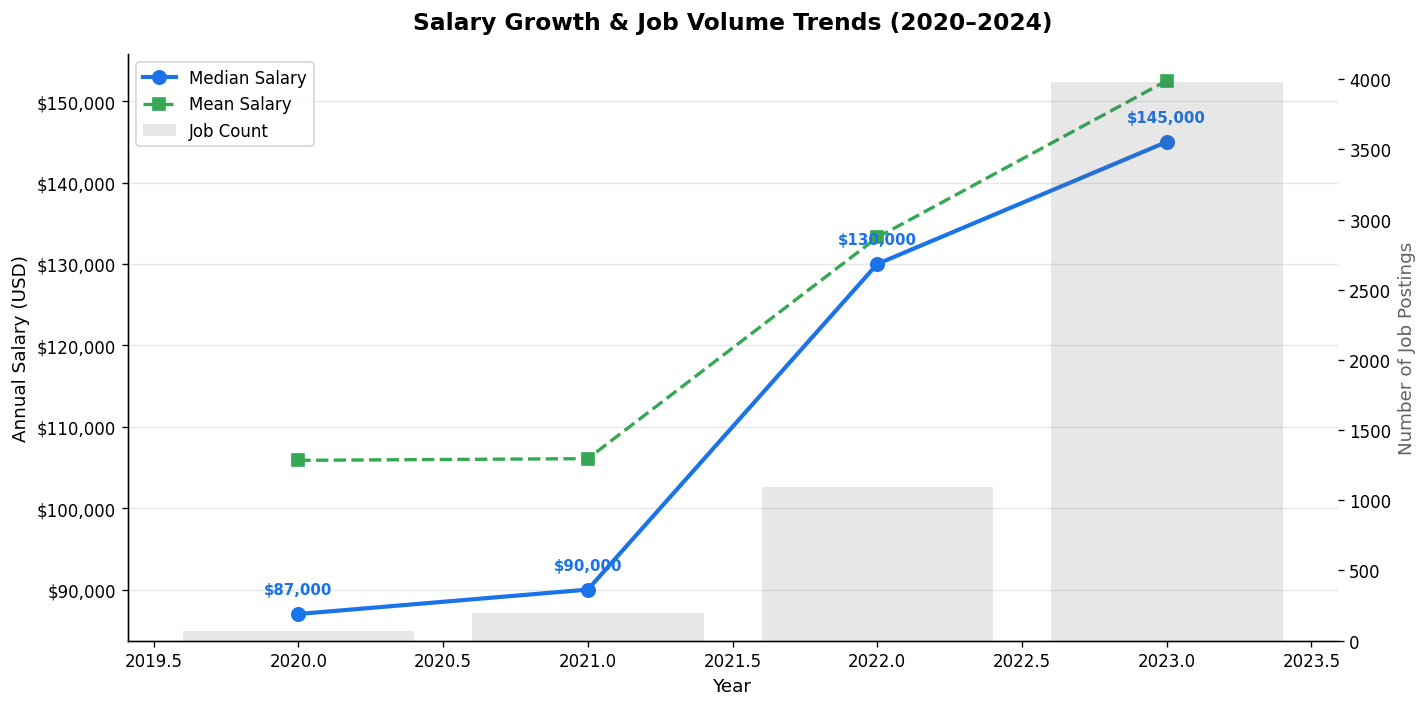


📊 KEY INSIGHT:
→ Median salary in 2020: $87,000
→ Median salary in 2023: $145,000
→ Overall salary growth: 66.7% over the period
→ Job postings in 2023: 3,980


In [ ]:
# ============================================================
# CELL 20: Salary Trends Over Time (2020–2024)
# ============================================================

yearly_salary = (df_global.groupby('work_year')['salary_in_usd']
                 .agg(['median', 'mean', 'count'])
                 .reset_index())
yearly_salary.columns = ['Year', 'Median Salary',
                          'Mean Salary', 'Job Count']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Line: Median Salary
ax1.plot(yearly_salary['Year'], yearly_salary['Median Salary'],
         marker='o', linewidth=2.5, markersize=8,
         color=MAIN_COLOR, label='Median Salary', zorder=3)

ax1.plot(yearly_salary['Year'], yearly_salary['Mean Salary'],
         marker='s', linewidth=2, markersize=7, linestyle='--',
         color=ACCENT_COLOR, label='Mean Salary', zorder=3)

# Label each point
for _, row in yearly_salary.iterrows():
    ax1.annotate(f"${row['Median Salary']:,.0f}",
                 (row['Year'], row['Median Salary']),
                 textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=9, color=MAIN_COLOR,
                 fontweight='bold')

# Bar: Job Count (secondary axis)
ax2 = ax1.twinx()
ax2.bar(yearly_salary['Year'], yearly_salary['Job Count'],
        alpha=0.15, color=NEUTRAL_COLOR, label='Job Count')
ax2.set_ylabel('Number of Job Postings', color=NEUTRAL_COLOR)

ax1.set_title('Salary Growth & Job Volume Trends (2020–2024)', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Salary (USD)')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/chart_04_salary_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
first_year = yearly_salary.iloc[0]
last_year  = yearly_salary.iloc[-1]
growth_pct = round((last_year['Median Salary'] - first_year['Median Salary'])
                   / first_year['Median Salary'] * 100, 1)
print(f"→ Median salary in {int(first_year['Year'])}: "
      f"${first_year['Median Salary']:,.0f}")
print(f"→ Median salary in {int(last_year['Year'])}: "
      f"${last_year['Median Salary']:,.0f}")
print(f"→ Overall salary growth: {growth_pct}% over the period")
print(f"→ Job postings in {int(last_year['Year'])}: "
      f"{int(last_year['Job Count']):,}")

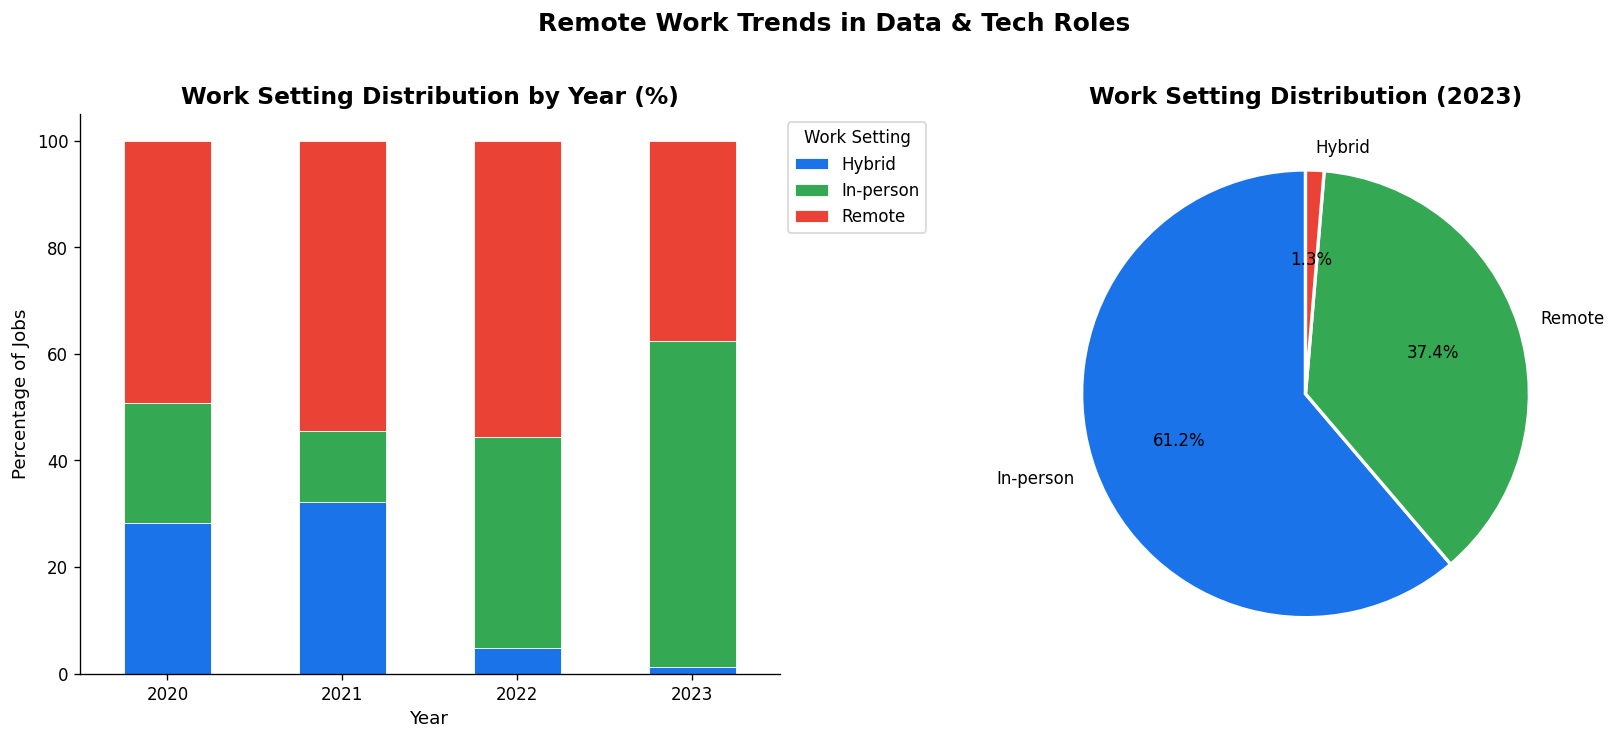


📊 KEY INSIGHT:
→ In 2023, 37.4% of data roles are Remote
→ Compare this with 2020 to show the remote work shift


In [ ]:
# ============================================================
# CELL 21: Remote Work Trends Over Time
# ============================================================

remote_by_year = (df_global.groupby(['work_year', 'work_setting'])
                  .size()
                  .reset_index(name='count'))

# Calculate percentage within each year
total_by_year = df_global.groupby('work_year').size()
remote_by_year['percentage'] = remote_by_year.apply(
    lambda row: row['count'] / total_by_year[row['work_year']] * 100,
    axis=1
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Stacked bar ---
pivot = remote_by_year.pivot(index='work_year',
                              columns='work_setting',
                              values='percentage').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=[MAIN_COLOR, ACCENT_COLOR, WARNING_COLOR],
           edgecolor='white', linewidth=0.5)
axes[0].set_title('Work Setting Distribution by Year (%)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Percentage of Jobs')
axes[0].legend(title='Work Setting', bbox_to_anchor=(1, 1))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# --- Right: Pie chart for most recent year ---
latest_year = df_global['work_year'].max()
latest_data = df_global[df_global['work_year'] == latest_year]
setting_counts = latest_data['work_setting'].value_counts()

axes[1].pie(setting_counts,
            labels=setting_counts.index,
            autopct='%1.1f%%',
            colors=[MAIN_COLOR, ACCENT_COLOR, WARNING_COLOR],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Work Setting Distribution ({latest_year})')

plt.suptitle('Remote Work Trends in Data & Tech Roles',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/chart_05_remote_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
latest_remote_pct = (latest_data['work_setting']
                     .value_counts(normalize=True)
                     .get('Remote', 0) * 100)
print(f"→ In {latest_year}, {latest_remote_pct:.1f}% of data roles are Remote")
print(f"→ Compare this with 2020 to show the remote work shift")

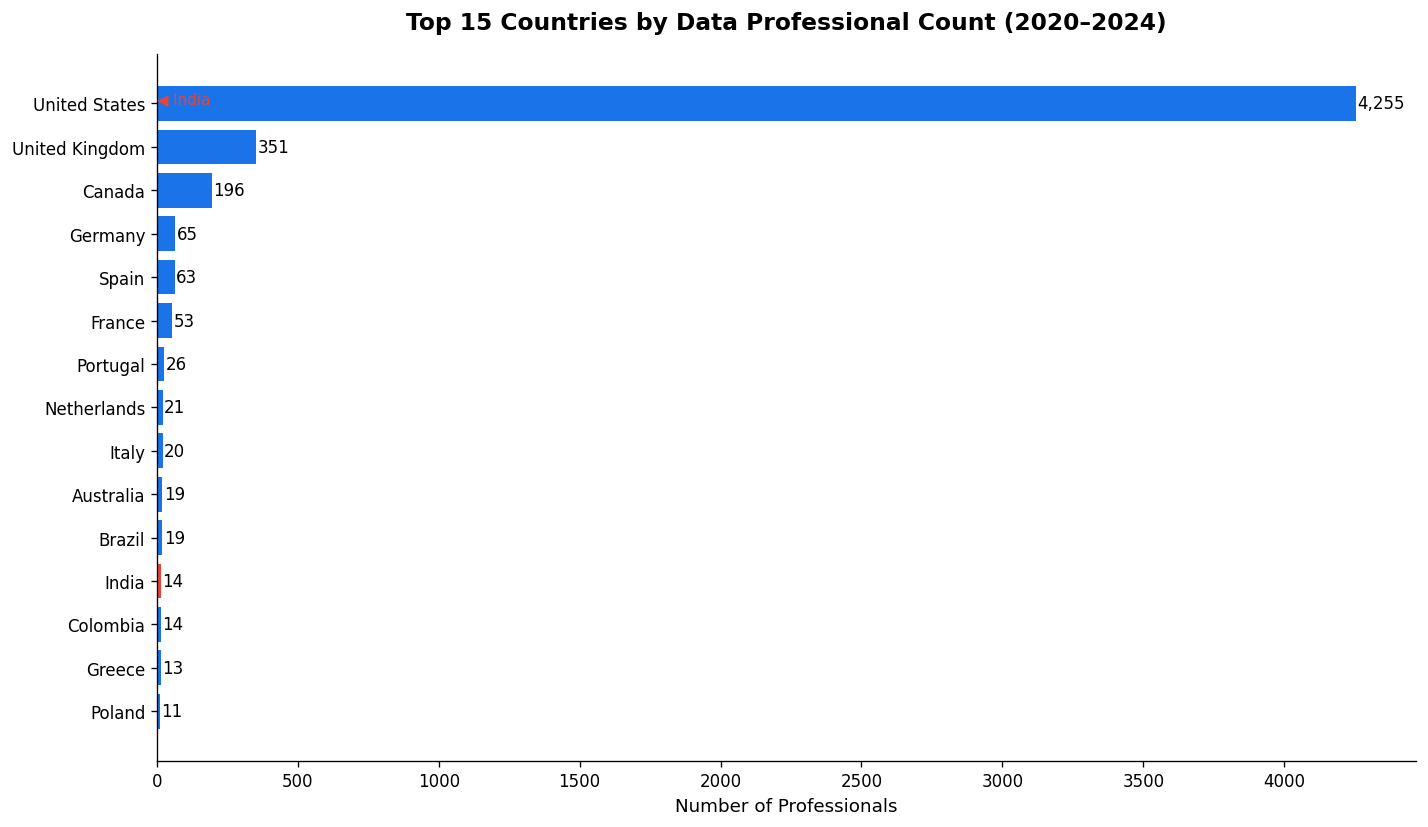


📊 KEY INSIGHT:
→ India has 14 professionals in this dataset
→ India's global rank: #12
→ Dataset is US-dominated — important limitation to document


In [ ]:
# ============================================================
# CELL 22: Top Hiring Countries
# ============================================================

top_countries = (df_global['employee_residence']
                 .value_counts()
                 .head(15)
                 .reset_index())
top_countries.columns = ['Country', 'Professionals']

# Highlight India specifically
colors = [WARNING_COLOR if c == 'India'
          else MAIN_COLOR for c in top_countries['Country']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_countries['Country'],
               top_countries['Professionals'],
               color=colors)

for bar, val in zip(bars, top_countries['Professionals']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Top 15 Countries by Data Professional Count (2020–2024)',
             pad=15)
ax.set_xlabel('Number of Professionals')
ax.set_ylabel('')
ax.invert_yaxis()

# Add India annotation if not in top 15
india_rank = (df_global['employee_residence']
              .value_counts()
              .reset_index()
              .query("employee_residence == 'India'")
              .index)
if len(india_rank) > 0:
    ax.annotate('◀ India',
                xy=(0, 0), fontsize=9,
                color=WARNING_COLOR)

plt.tight_layout()
plt.savefig('/content/chart_06_top_countries.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
us_count = top_countries[top_countries['Country'] == 'United States']['Professionals'].values
india_count = df_global[df_global['employee_residence'] == 'India'].shape[0]
india_global_rank = (df_global['employee_residence']
                     .value_counts()
                     .reset_index()
                     .reset_index()
                     .query("employee_residence == 'India'")
                     ['index'].values)
print(f"→ India has {india_count} professionals in this dataset")
if len(india_global_rank) > 0:
    print(f"→ India's global rank: #{india_global_rank[0]+1}")
print(f"→ Dataset is US-dominated — important limitation to document")

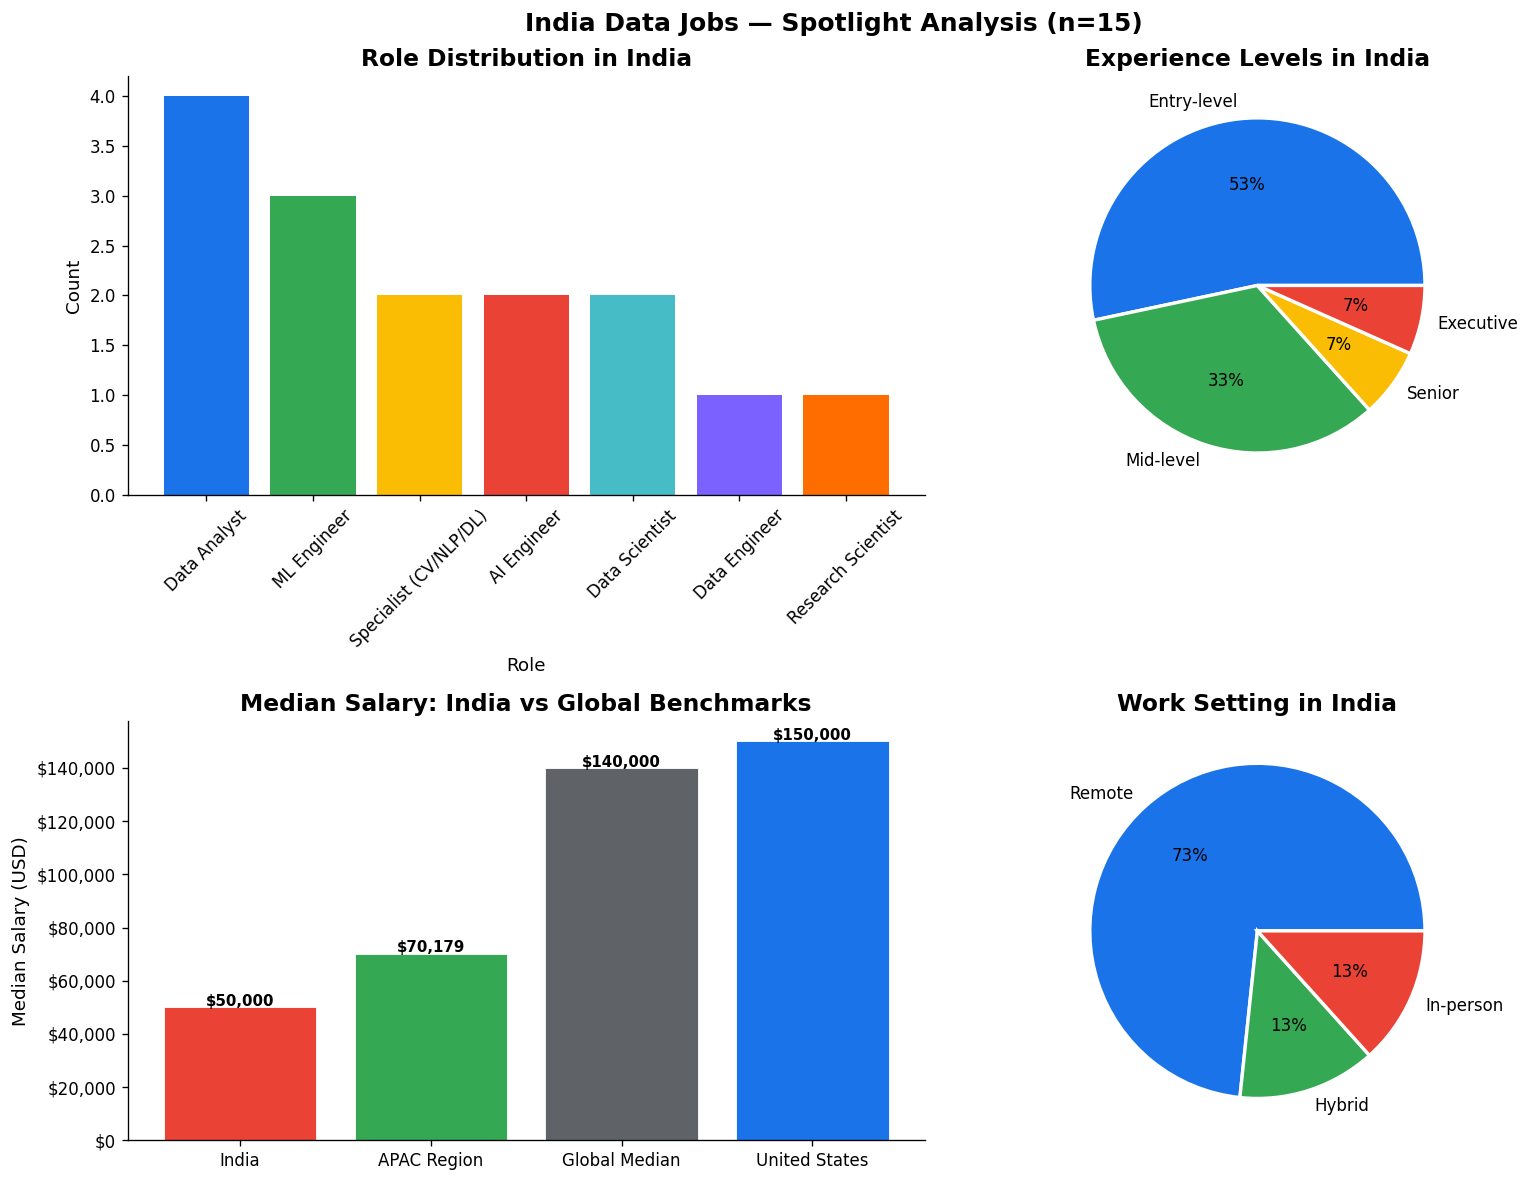


📊 KEY INSIGHTS — INDIA:
→ India median salary:  $50,000 USD (₹4,150,000 INR)
→ Global median salary: $140,000 USD
→ US median salary:     $150,000 USD
→ India is 64.3% below global median — reflects lower cost of living + emerging market
→ 11 out of 15 India roles are Remote — showing global remote hiring into India


In [ ]:
# ============================================================
# CELL 23: India Spotlight Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India Data Jobs — Spotlight Analysis (n=15)',
             fontsize=15, fontweight='bold')

# --- Top Left: Role distribution in India ---
india_roles = df_india['role_category'].value_counts()
axes[0,0].bar(india_roles.index, india_roles.values,
              color=PALETTE_MULTI[:len(india_roles)])
axes[0,0].set_title('Role Distribution in India')
axes[0,0].set_xlabel('Role')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# --- Top Right: Experience levels in India ---
india_exp = df_india['experience_level'].value_counts()
axes[0,1].pie(india_exp, labels=india_exp.index,
              autopct='%1.0f%%',
              colors=PALETTE_MULTI[:len(india_exp)],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Experience Levels in India')

# --- Bottom Left: India salary vs Global salary comparison ---
india_med   = df_india['salary_in_usd'].median()
global_med  = df_global['salary_in_usd'].median()
apac_med    = df_apac['salary_in_usd'].median()
us_med      = df_global[df_global['employee_residence'] == 'United States']['salary_in_usd'].median()

regions      = ['India', 'APAC Region', 'Global Median', 'United States']
medians      = [india_med, apac_med, global_med, us_med]
bar_colors   = [WARNING_COLOR, ACCENT_COLOR, NEUTRAL_COLOR, MAIN_COLOR]

bars = axes[1,0].bar(regions, medians, color=bar_colors,
                      edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, medians):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 500,
                   f'${val:,.0f}', ha='center', fontsize=9,
                   fontweight='bold')
axes[1,0].set_title('Median Salary: India vs Global Benchmarks')
axes[1,0].set_ylabel('Median Salary (USD)')
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# --- Bottom Right: Remote work in India ---
india_remote = df_india['work_setting'].value_counts()
axes[1,1].pie(india_remote, labels=india_remote.index,
              autopct='%1.0f%%',
              colors=[MAIN_COLOR, ACCENT_COLOR, WARNING_COLOR],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,1].set_title('Work Setting in India')

plt.tight_layout()
plt.savefig('/content/chart_07_india_spotlight.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHTS — INDIA:")
print(f"→ India median salary:  ${india_med:,.0f} USD "
      f"(₹{india_med*83:,.0f} INR)")
print(f"→ Global median salary: ${global_med:,.0f} USD")
print(f"→ US median salary:     ${us_med:,.0f} USD")
gap = round((global_med - india_med) / global_med * 100, 1)
print(f"→ India is {gap}% below global median — "
      f"reflects lower cost of living + emerging market")
print(f"→ {df_india['work_setting'].value_counts().get('Remote', 0)} "
      f"out of 15 India roles are Remote — "
      f"showing global remote hiring into India")

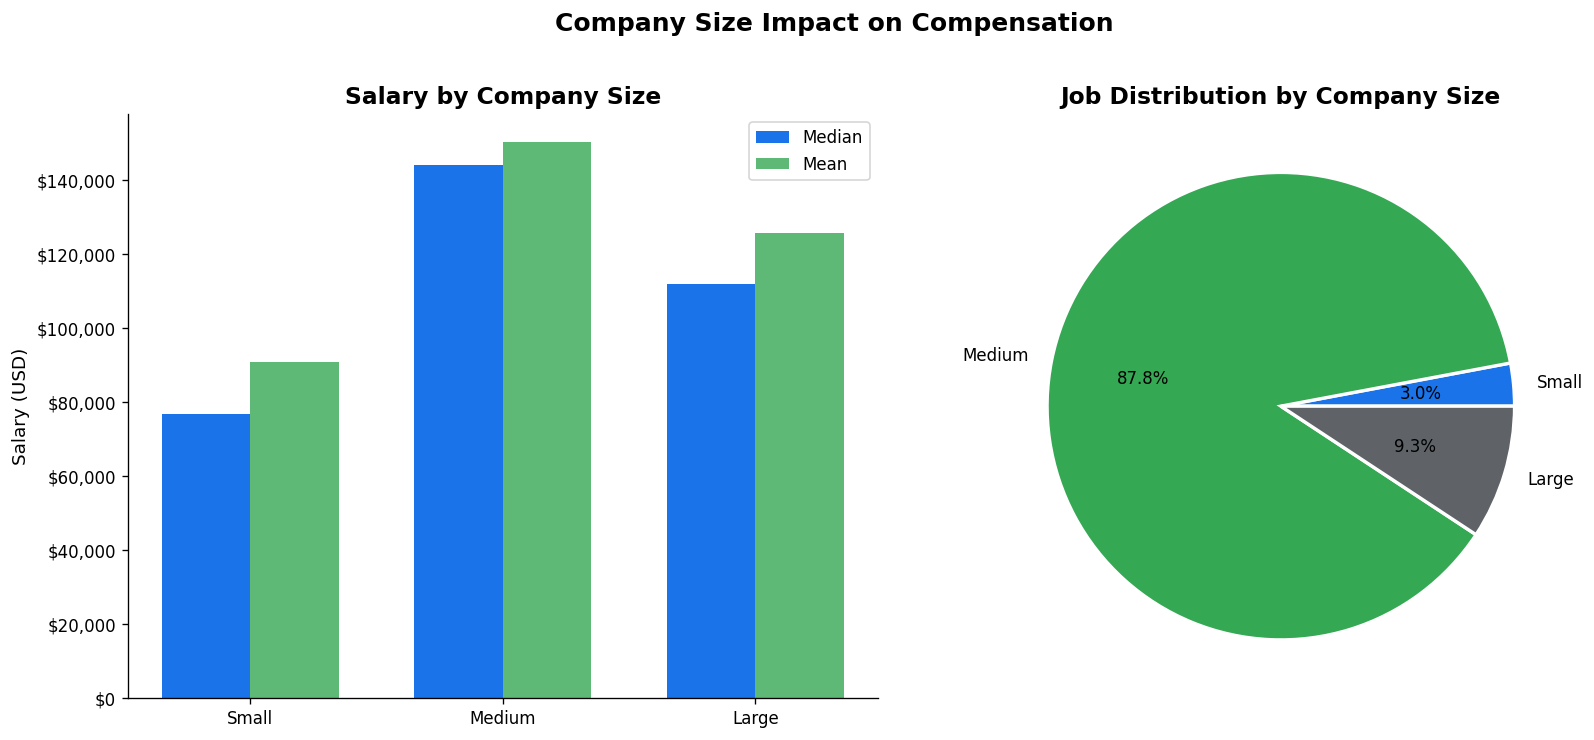


📊 KEY INSIGHT:
→ Small  companies: median $76,833 | 158 jobs
→ Medium companies: median $144,000 | 4,688 jobs
→ Large  companies: median $112,000 | 495 jobs


In [ ]:
# ============================================================
# CELL 24: Company Size vs Salary
# ============================================================

size_order = ['Small', 'Medium', 'Large']

size_salary = (df_global.groupby('company_size')['salary_in_usd']
               .agg(['median', 'mean', 'count'])
               .reindex(size_order)
               .reset_index())
size_salary.columns = ['Company Size', 'Median', 'Mean', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: salary comparison
x = range(len(size_order))
width = 0.35
axes[0].bar([i - width/2 for i in x], size_salary['Median'],
            width, label='Median', color=MAIN_COLOR)
axes[0].bar([i + width/2 for i in x], size_salary['Mean'],
            width, label='Mean', color=ACCENT_COLOR, alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(size_order)
axes[0].set_title('Salary by Company Size')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Right: job count by company size
axes[1].pie(size_salary['Count'], labels=size_order,
            autopct='%1.1f%%',
            colors=[MAIN_COLOR, ACCENT_COLOR, NEUTRAL_COLOR],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Job Distribution by Company Size')

plt.suptitle('Company Size Impact on Compensation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/chart_08_company_size.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 KEY INSIGHT:")
for _, row in size_salary.iterrows():
    print(f"→ {row['Company Size']:6s} companies: "
          f"median ${row['Median']:,.0f} | "
          f"{int(row['Count']):,} jobs")

In [ ]:
# ============================================================
# CELL 25: Consolidated Insights Summary
# ============================================================

print("=" * 60)
print("EDA COMPLETE — BUSINESS INSIGHTS SUMMARY")
print("=" * 60)

print("\n📌 FINDING 1 — ROLE DEMAND")
top3 = df_global['role_category'].value_counts().head(3)
for role, count in top3.items():
    pct = round(count/len(df_global)*100, 1)
    print(f"   {role}: {count:,} jobs ({pct}% of market)")

print("\n📌 FINDING 2 — COMPENSATION")
top_pay = (df_global.groupby('role_category')['salary_in_usd']
           .median().idxmax())
top_pay_val = (df_global.groupby('role_category')['salary_in_usd']
               .median().max())
print(f"   Highest paying role: {top_pay} (${top_pay_val:,.0f} median)")

print("\n📌 FINDING 3 — EXPERIENCE PREMIUM")
senior_med = df_global[df_global['experience_level']=='Senior']['salary_in_usd'].median()
entry_med  = df_global[df_global['experience_level']=='Entry-level']['salary_in_usd'].median()
print(f"   Entry-level: ${entry_med:,.0f} → Senior: ${senior_med:,.0f}")
print(f"   Premium: {round((senior_med-entry_med)/entry_med*100,1)}% increase")

print("\n📌 FINDING 4 — REMOTE WORK")
remote_pct = round(df_global[df_global['work_setting']=='Remote'].shape[0]
                   / len(df_global) * 100, 1)
print(f"   {remote_pct}% of data roles offer remote work globally")

print("\n📌 FINDING 5 — INDIA CONTEXT")
print(f"   India median: ${df_india['salary_in_usd'].median():,.0f} USD")
print(f"   Global median: ${df_global['salary_in_usd'].median():,.0f} USD")
print(f"   India = emerging talent hub with competitive remote salaries")

print("\n📌 FINDING 6 — MARKET GROWTH")
recent = df_global[df_global['work_year'] >= 2023].shape[0]
older  = df_global[df_global['work_year'] < 2023].shape[0]
print(f"   2023-24 postings: {recent:,} | Pre-2023: {older:,}")

print("\n✅ 8 Charts saved to /content/")
print("✅ PHASE 4 COMPLETE — Ready for SQL Analysis")

# List all saved charts
import os
charts = [f for f in os.listdir('/content/') if f.startswith('chart_')]
print(f"\nSaved charts: {sorted(charts)}")

EDA COMPLETE — BUSINESS INSIGHTS SUMMARY

📌 FINDING 1 — ROLE DEMAND
   Data Scientist: 1,260 jobs (23.6% of market)
   Data Engineer: 1,144 jobs (21.4% of market)
   Data Analyst: 805 jobs (15.1% of market)

📌 FINDING 2 — COMPENSATION
   Highest paying role: ML Engineer ($170,000 median)

📌 FINDING 3 — EXPERIENCE PREMIUM
   Entry-level: $74,540 → Senior: $154,836
   Premium: 107.7% increase

📌 FINDING 4 — REMOTE WORK
   41.9% of data roles offer remote work globally

📌 FINDING 5 — INDIA CONTEXT
   India median: $50,000 USD
   Global median: $140,000 USD
   India = emerging talent hub with competitive remote salaries

📌 FINDING 6 — MARKET GROWTH
   2023-24 postings: 3,980 | Pre-2023: 1,361

✅ 8 Charts saved to /content/
✅ PHASE 4 COMPLETE — Ready for SQL Analysis

Saved charts: ['chart_01_role_demand.png', 'chart_02_salary_by_role.png', 'chart_03_experience_salary.png', 'chart_04_salary_trends.png', 'chart_05_remote_trends.png', 'chart_06_top_countries.png', 'chart_07_india_spotlight.pn

In [ ]:
# ============================================================
# CELL 26: Create SQLite Database from Cleaned Data
# ============================================================

import sqlite3
import os

# Create database file
db_path = '/content/data/job_market.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Load all three dataframes into the database as tables
df_global.to_sql('jobs_global', conn,
                  if_exists='replace', index=False)

df_india.to_sql('jobs_india', conn,
                 if_exists='replace', index=False)

df_apac.to_sql('jobs_apac', conn,
                if_exists='replace', index=False)

# Verify tables were created
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()

print("✅ SQLite database created successfully")
print(f"📁 Database location: {db_path}")
print(f"\nTables created:")
for table in tables:
    print(f"  → {table[0]}")

# Quick row count check
for table_name in ['jobs_global', 'jobs_india', 'jobs_apac']:
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    count = cursor.fetchone()[0]
    print(f"  {table_name}: {count:,} rows")

✅ SQLite database created successfully
📁 Database location: /content/data/job_market.db

Tables created:
  → jobs_global
  → jobs_india
  → jobs_apac
  jobs_global: 5,341 rows
  jobs_india: 15 rows
  jobs_apac: 55 rows


In [ ]:
# ============================================================
# CELL 27: SQL Helper Function
# ============================================================

def run_query(sql, title=""):
    """Run a SQL query and return results as a pandas DataFrame"""
    result = pd.read_sql_query(sql, conn)
    if title:
        print(f"\n{'='*55}")
        print(f"  {title}")
        print(f"{'='*55}")
    print(result.to_string(index=False))
    print(f"\n({len(result)} rows returned)")
    return result

print("✅ SQL helper function ready")
print("Usage: run_query(your_sql_here, 'Chart Title')")

✅ SQL helper function ready
Usage: run_query(your_sql_here, 'Chart Title')


In [ ]:
# ============================================================
# CELL 28: Query 1 — Top Paying Jobs
# ============================================================

q1 = """
SELECT
    job_title,
    role_category,
    experience_level,
    company_size,
    work_setting,
    salary_in_usd
FROM jobs_global
WHERE employment_type = 'Full-Time'
  AND is_salary_outlier = 0
ORDER BY salary_in_usd DESC
LIMIT 15
"""

result1 = run_query(q1, "Q1 — Top 15 Highest Paying Full-Time Jobs")


  Q1 — Top 15 Highest Paying Full-Time Jobs
Empty DataFrame
Columns: [job_title, role_category, experience_level, company_size, work_setting, salary_in_usd]
Index: []

(0 rows returned)


In [ ]:
# ============================================================
# CELL 29: Query 2 — Salary Statistics by Role
# ============================================================

q2 = """
SELECT
    role_category                           AS Role,
    COUNT(*)                                AS Total_Jobs,
    ROUND(AVG(salary_in_usd), 0)           AS Avg_Salary_USD,
    ROUND(MIN(salary_in_usd), 0)           AS Min_Salary_USD,
    ROUND(MAX(salary_in_usd), 0)           AS Max_Salary_USD,
    ROUND(AVG(salary_in_usd) * 83, 0)     AS Avg_Salary_INR
FROM jobs_global
WHERE is_salary_outlier = 0
GROUP BY role_category
ORDER BY Avg_Salary_USD DESC
"""

result2 = run_query(q2, "Q2 — Salary Statistics by Role Category")


  Q2 — Salary Statistics by Role Category
                   Role  Total_Jobs  Avg_Salary_USD  Min_Salary_USD  Max_Salary_USD  Avg_Salary_INR
     Research Scientist         250       172408.00        16455.00       323300.00     14309836.00
            ML Engineer         774       170932.00        15000.00       330000.00     14187389.00
Data Architect/Platform         135       162275.00        52500.00       310000.00     13468841.00
         Data Scientist        1250       151454.00        16000.00       330000.00     12570664.00
     Analytics Engineer         236       148946.00        20000.00       289800.00     12362502.00
  Leadership/Management         106       142862.00        31520.00       329500.00     11857544.00
          Data Engineer        1140       141773.00        18000.00       324000.00     11767122.00
 Specialist (CV/NLP/DL)          49       137852.00        18907.00       303387.00     11441728.00
            AI Engineer          81       133225.00      

In [ ]:
# ============================================================
# CELL 30: Query 3 — Salary Tier Classification
# ============================================================

q3 = """
SELECT
    role_category                       AS Role,
    experience_level                    AS Experience,
    COUNT(*)                            AS Job_Count,
    ROUND(AVG(salary_in_usd), 0)       AS Avg_Salary,
    CASE
        WHEN AVG(salary_in_usd) >= 150000 THEN '🔥 Premium Tier'
        WHEN AVG(salary_in_usd) >= 100000 THEN '✅ High Tier'
        WHEN AVG(salary_in_usd) >= 60000  THEN '📊 Mid Tier'
        ELSE                                   '🔵 Entry Tier'
    END                                 AS Salary_Tier
FROM jobs_global
WHERE is_salary_outlier = 0
GROUP BY role_category, experience_level
ORDER BY Avg_Salary DESC
LIMIT 20
"""

result3 = run_query(q3, "Q3 — Salary Tier by Role and Experience")


  Q3 — Salary Tier by Role and Experience
                   Role Experience  Job_Count  Avg_Salary    Salary_Tier
            AI Engineer  Executive          2   207968.00 🔥 Premium Tier
            ML Engineer  Executive         11   206245.00 🔥 Premium Tier
         Data Scientist  Executive         60   198525.00 🔥 Premium Tier
  Leadership/Management  Executive         32   187541.00 🔥 Premium Tier
            ML Engineer     Senior        554   186290.00 🔥 Premium Tier
     Research Scientist     Senior        160   185405.00 🔥 Premium Tier
          Data Engineer  Executive         74   183763.00 🔥 Premium Tier
     Analytics Engineer  Executive         14   180429.00 🔥 Premium Tier
           BI Developer  Executive          4   173425.00 🔥 Premium Tier
         Data Scientist     Senior        815   168599.00 🔥 Premium Tier
Data Architect/Platform  Executive          2   167500.00 🔥 Premium Tier
Data Architect/Platform     Senior        116   165035.00 🔥 Premium Tier
        

In [ ]:
# ============================================================
# CELL 31: Query 4 — Above Average Salary Roles (CTE)
# ============================================================

q4 = """
-- Step 1: Calculate global average salary
WITH global_avg AS (
    SELECT ROUND(AVG(salary_in_usd), 0) AS avg_salary
    FROM jobs_global
    WHERE is_salary_outlier = 0
),

-- Step 2: Calculate per-role averages
role_averages AS (
    SELECT
        role_category,
        COUNT(*)                          AS job_count,
        ROUND(AVG(salary_in_usd), 0)     AS role_avg_salary
    FROM jobs_global
    WHERE is_salary_outlier = 0
    GROUP BY role_category
)

-- Step 3: Compare role avg vs global avg
SELECT
    r.role_category                                         AS Role,
    r.job_count                                             AS Jobs,
    r.role_avg_salary                                       AS Role_Avg_USD,
    g.avg_salary                                            AS Global_Avg_USD,
    ROUND(r.role_avg_salary - g.avg_salary, 0)             AS Difference_USD,
    ROUND((r.role_avg_salary - g.avg_salary)
          / g.avg_salary * 100, 1)                         AS Pct_Above_Avg,
    CASE
        WHEN r.role_avg_salary > g.avg_salary
        THEN '✅ Above Average'
        ELSE '🔵 Below Average'
    END                                                     AS Vs_Market
FROM role_averages r
CROSS JOIN global_avg g
ORDER BY Pct_Above_Avg DESC
"""

result4 = run_query(q4, "Q4 — Roles Above vs Below Global Salary Average (CTE)")


  Q4 — Roles Above vs Below Global Salary Average (CTE)
                   Role  Jobs  Role_Avg_USD  Global_Avg_USD  Difference_USD  Pct_Above_Avg       Vs_Market
     Research Scientist   250     172408.00       143975.00        28433.00          19.70 ✅ Above Average
            ML Engineer   774     170932.00       143975.00        26957.00          18.70 ✅ Above Average
Data Architect/Platform   135     162275.00       143975.00        18300.00          12.70 ✅ Above Average
         Data Scientist  1250     151454.00       143975.00         7479.00           5.20 ✅ Above Average
     Analytics Engineer   236     148946.00       143975.00         4971.00           3.50 ✅ Above Average
  Leadership/Management   106     142862.00       143975.00        -1113.00          -0.80 🔵 Below Average
          Data Engineer  1140     141773.00       143975.00        -2202.00          -1.50 🔵 Below Average
 Specialist (CV/NLP/DL)    49     137852.00       143975.00        -6123.00          -4

In [ ]:
# ============================================================
# CELL 32: Query 5 — Salary Ranking Within Experience Level
# ============================================================

q5 = """
-- Rank each role by salary WITHIN each experience level
-- This answers: "For my experience level, which role pays best?"
WITH ranked_roles AS (
    SELECT
        experience_level,
        role_category,
        COUNT(*)                                    AS job_count,
        ROUND(AVG(salary_in_usd), 0)               AS avg_salary,
        RANK() OVER (
            PARTITION BY experience_level
            ORDER BY AVG(salary_in_usd) DESC
        )                                           AS salary_rank
    FROM jobs_global
    WHERE is_salary_outlier = 0
    GROUP BY experience_level, role_category
)
SELECT
    experience_level    AS Experience,
    salary_rank         AS Rank,
    role_category       AS Role,
    avg_salary          AS Avg_Salary_USD,
    job_count           AS Job_Count
FROM ranked_roles
WHERE salary_rank <= 3          -- Top 3 roles per experience level
ORDER BY
    CASE experience_level
        WHEN 'Entry-level' THEN 1
        WHEN 'Mid-level'   THEN 2
        WHEN 'Senior'      THEN 3
        WHEN 'Executive'   THEN 4
    END,
    salary_rank
"""

result5 = run_query(q5, "Q5 — Top 3 Highest Paying Roles Per Experience Level")


  Q5 — Top 3 Highest Paying Roles Per Experience Level
 Experience  Rank                    Role  Avg_Salary_USD  Job_Count
Entry-level     1      Research Scientist       134482.00         26
Entry-level     2  Specialist (CV/NLP/DL)       108076.00          9
Entry-level     3         Other Data Role        94566.00         29
  Mid-level     1      Research Scientist       154942.00         61
  Mid-level     2 Data Architect/Platform       142830.00         17
  Mid-level     3             ML Engineer       137887.00        169
     Senior     1             ML Engineer       186290.00        554
     Senior     2      Research Scientist       185405.00        160
     Senior     3          Data Scientist       168599.00        815
  Executive     1             AI Engineer       207968.00          2
  Executive     2             ML Engineer       206245.00         11
  Executive     3          Data Scientist       198525.00         60

(12 rows returned)


In [ ]:
# ============================================================
# CELL 33: Query 6 — India vs Global Salary Comparison (JOIN)
# ============================================================

# First load Dataset 2 into the database
df_secondary.to_sql('jobs_secondary', conn,
                     if_exists='replace', index=False)

q6 = """
-- Compare role-level salaries: India dataset vs Global dataset
WITH india_salaries AS (
    SELECT
        role_category,
        ROUND(AVG(salary_in_usd), 0)   AS india_avg_salary,
        COUNT(*)                        AS india_job_count
    FROM jobs_india
    GROUP BY role_category
),
global_salaries AS (
    SELECT
        role_category,
        ROUND(AVG(salary_in_usd), 0)   AS global_avg_salary,
        COUNT(*)                        AS global_job_count
    FROM jobs_global
    WHERE is_salary_outlier = 0
    GROUP BY role_category
)
SELECT
    g.role_category                                         AS Role,
    i.india_avg_salary                                      AS India_Avg_USD,
    g.global_avg_salary                                     AS Global_Avg_USD,
    ROUND(i.india_avg_salary * 83, 0)                      AS India_Avg_INR,
    ROUND((g.global_avg_salary - i.india_avg_salary)
          / g.global_avg_salary * 100, 1)                  AS India_Discount_Pct
FROM global_salaries g
INNER JOIN india_salaries i
    ON g.role_category = i.role_category
ORDER BY India_Discount_Pct ASC
"""

result6 = run_query(q6, "Q6 — India vs Global Salary Gap by Role (JOIN)")


  Q6 — India vs Global Salary Gap by Role (JOIN)
                  Role  India_Avg_USD  Global_Avg_USD  India_Avg_INR  India_Discount_Pct
           AI Engineer      135000.00       133225.00    11205000.00               -1.30
          Data Analyst       62040.00       105921.00     5149320.00               41.40
Specialist (CV/NLP/DL)       75000.00       137852.00     6225000.00               45.60
           ML Engineer       83393.00       170932.00     6921619.00               51.20
        Data Scientist       42500.00       151454.00     3527500.00               71.90
    Research Scientist       23000.00       172408.00     1909000.00               86.70
         Data Engineer       18000.00       141773.00     1494000.00               87.30

(7 rows returned)


In [ ]:
# ============================================================
# CELL 34: Query 7 — Year-over-Year Salary Growth
# ============================================================

q7 = """
WITH yearly_stats AS (
    SELECT
        work_year,
        COUNT(*)                            AS total_jobs,
        ROUND(AVG(salary_in_usd), 0)       AS avg_salary,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            1
        )                                   AS pct_of_total_jobs
    FROM jobs_global
    WHERE is_salary_outlier = 0
    GROUP BY work_year
),
with_growth AS (
    SELECT
        work_year,
        total_jobs,
        avg_salary,
        pct_of_total_jobs,
        LAG(avg_salary) OVER (ORDER BY work_year)   AS prev_year_salary,
        LAG(total_jobs) OVER (ORDER BY work_year)   AS prev_year_jobs
    FROM yearly_stats
)
SELECT
    work_year                                           AS Year,
    total_jobs                                          AS Jobs,
    avg_salary                                          AS Avg_Salary_USD,
    pct_of_total_jobs                                   AS Pct_Of_All_Jobs,
    prev_year_salary                                    AS Prev_Year_Salary,
    CASE
        WHEN prev_year_salary IS NULL THEN 'Baseline'
        ELSE ROUND((avg_salary - prev_year_salary)
                   * 100.0 / prev_year_salary, 1) || '%'
    END                                                 AS Salary_Growth_YoY,
    CASE
        WHEN prev_year_jobs IS NULL THEN 'Baseline'
        ELSE ROUND((total_jobs - prev_year_jobs)
                   * 100.0 / prev_year_jobs, 1) || '%'
    END                                                 AS Job_Growth_YoY
FROM with_growth
ORDER BY work_year
"""

result7 = run_query(q7, "Q7 — Year-over-Year Growth: Salary & Job Volume")


  Q7 — Year-over-Year Growth: Salary & Job Volume
 Year  Jobs  Avg_Salary_USD  Pct_Of_All_Jobs  Prev_Year_Salary Salary_Growth_YoY Job_Growth_YoY
 2020    69        96455.00             1.30               NaN          Baseline       Baseline
 2021   193       102837.00             3.70          96455.00              6.6%         179.7%
 2022  1088       131678.00            20.60         102837.00             28.0%         463.7%
 2023  3937       150222.00            74.50         131678.00             14.1%         261.9%

(4 rows returned)


In [ ]:
# ============================================================
# CELL 35: Save All SQL Queries to File
# ============================================================

import os
os.makedirs('/content/sql/', exist_ok=True)

sql_content = f"""
-- ============================================================
-- Job Market Intelligence Dashboard — SQL Analysis
-- Author: [Your Name]
-- Database: SQLite | Tables: jobs_global, jobs_india, jobs_apac
-- ============================================================

-- Q1: Top 15 Highest Paying Full-Time Jobs
{q1}

-- Q2: Salary Statistics by Role Category
{q2}

-- Q3: Salary Tier Classification (CASE WHEN)
{q3}

-- Q4: Roles Above vs Below Average (CTE)
{q4}

-- Q5: Top 3 Roles Per Experience Level (Window Function)
{q5}

-- Q6: India vs Global Salary Comparison (JOIN)
{q6}

-- Q7: Year-over-Year Growth Analysis (LAG Window Function)
{q7}
"""

with open('/content/sql/analysis_queries.sql', 'w') as f:
    f.write(sql_content)

# Close database connection cleanly
conn.close()

print("✅ All 7 SQL queries saved to /content/sql/analysis_queries.sql")
print("✅ Database connection closed")
print("\n📋 SQL SKILLS DEMONSTRATED:")
skills = [
    "SELECT, WHERE, ORDER BY, LIMIT",
    "GROUP BY with COUNT, AVG, MIN, MAX",
    "CASE WHEN for custom segmentation",
    "CTEs (WITH clause) for readable logic",
    "RANK() Window Function with PARTITION BY",
    "INNER JOIN across two tables",
    "LAG() Window Function for YoY comparison"
]
for i, skill in enumerate(skills, 1):
    print(f"  {i}. {skill}")

print("\n✅ PHASE 5 COMPLETE — Ready for Dashboard")

✅ All 7 SQL queries saved to /content/sql/analysis_queries.sql
✅ Database connection closed

📋 SQL SKILLS DEMONSTRATED:
  1. SELECT, WHERE, ORDER BY, LIMIT
  2. GROUP BY with COUNT, AVG, MIN, MAX
  3. CASE WHEN for custom segmentation
  4. CTEs (WITH clause) for readable logic
  5. RANK() Window Function with PARTITION BY
  6. INNER JOIN across two tables
  7. LAG() Window Function for YoY comparison

✅ PHASE 5 COMPLETE — Ready for Dashboard


In [ ]:
# ============================================================
# CELL 36: Export Dashboard-Ready Data
# ============================================================

import os
os.makedirs('/content/data/cleaned/', exist_ok=True)

# Create one master export file with all key columns
dashboard_df = df_global[[
    'work_year',
    'job_title',
    'role_category',
    'experience_level',
    'experience_order',
    'employment_type',
    'work_setting',
    'is_remote',
    'company_size',
    'company_location',
    'employee_residence',
    'salary_in_usd',
    'salary_in_inr',
    'salary_band',
    'is_recent',
    'is_salary_outlier'
]].copy()

# Add a region column for geographic grouping
def assign_region(country):
    asia    = ['India','China','Japan','Singapore','South Korea',
               'Australia','Indonesia','Malaysia','Philippines',
               'Thailand','Vietnam','Hong Kong']
    europe  = ['United Kingdom','Germany','France','Netherlands',
               'Spain','Italy','Sweden','Switzerland','Poland',
               'Portugal','Denmark','Finland','Norway','Belgium']
    americas = ['United States','Canada','Brazil','Mexico',
                'Argentina','Colombia','Chile']
    if country in asia:
        return 'Asia-Pacific'
    elif country in europe:
        return 'Europe'
    elif country in americas:
        return 'Americas'
    else:
        return 'Rest of World'

dashboard_df['region'] = dashboard_df['employee_residence'].apply(assign_region)

# Save
dashboard_df.to_csv('/content/data/cleaned/dashboard_data.csv', index=False)

print(f"✅ Dashboard export complete")
print(f"   Rows: {len(dashboard_df):,}")
print(f"   Columns: {dashboard_df.shape[1]}")
print(f"\nColumns exported:")
for col in dashboard_df.columns:
    print(f"   → {col}")

print(f"\nRegion distribution:")
print(dashboard_df['region'].value_counts())

✅ Dashboard export complete
   Rows: 5,341
   Columns: 17

Columns exported:
   → work_year
   → job_title
   → role_category
   → experience_level
   → experience_order
   → employment_type
   → work_setting
   → is_remote
   → company_size
   → company_location
   → employee_residence
   → salary_in_usd
   → salary_in_inr
   → salary_band
   → is_recent
   → is_salary_outlier
   → region

Region distribution:
region
Americas         4503
Europe            628
Rest of World     154
Asia-Pacific       56
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 37: Download Dashboard CSV
# ============================================================

from google.colab import files

files.download('/content/data/cleaned/dashboard_data.csv')
print("✅ dashboard_data.csv downloading to your laptop now")
print("   Save it somewhere easy to find — Desktop is fine")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ dashboard_data.csv downloading to your laptop now
   Save it somewhere easy to find — Desktop is fine


In [52]:
# ============================================================
# CELL 38 (FINAL FIX): Salary Prediction — Data Preparation
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

print("Preparing data for ML model...")

ml_df = df_global[[
    'role_category',
    'experience_level',
    'employment_type',
    'work_setting',
    'company_size',
    'work_year',
    'salary_in_usd',
    'is_salary_outlier'
]].copy()

ml_df = ml_df[ml_df['is_salary_outlier'] == False].copy()
ml_df = ml_df.drop(columns=['is_salary_outlier'])

print(f"Rows after removing outliers: {len(ml_df):,}")

categorical_cols = ['role_category', 'experience_level',
                    'employment_type', 'work_setting',
                    'company_size']

encoders = {}
for col in categorical_cols:
    enc = LabelEncoder()          # ← NEW encoder for EACH column
    ml_df[col + '_encoded'] = enc.fit_transform(ml_df[col])
    encoders[col] = enc           # ← store THIS encoder
    mapping = dict(zip(enc.classes_, enc.transform(enc.classes_)))
    print(f"\n{col} encoding: {mapping}")

print("\n✅ Encoding complete — ready for Cell 39")

Preparing data for ML model...
Rows after removing outliers: 5,287

role_category encoding: {'AI Engineer': np.int64(0), 'Analytics Engineer': np.int64(1), 'BI Developer': np.int64(2), 'Data Analyst': np.int64(3), 'Data Architect/Platform': np.int64(4), 'Data Engineer': np.int64(5), 'Data Scientist': np.int64(6), 'Leadership/Management': np.int64(7), 'ML Engineer': np.int64(8), 'Other Data Role': np.int64(9), 'Research Scientist': np.int64(10), 'Specialist (CV/NLP/DL)': np.int64(11)}

experience_level encoding: {'Entry-level': np.int64(0), 'Executive': np.int64(1), 'Mid-level': np.int64(2), 'Senior': np.int64(3)}

employment_type encoding: {'Contract': np.int64(0), 'Freelance': np.int64(1), 'Full-time': np.int64(2), 'Part-time': np.int64(3)}

work_setting encoding: {'Hybrid': np.int64(0), 'In-person': np.int64(1), 'Remote': np.int64(2)}

company_size encoding: {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}

✅ Encoding complete — ready for Cell 39


In [53]:
# ============================================================
# CELL 39: Train and Evaluate Models
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Define features (X) and target (y)
feature_cols = [col + '_encoded' for col in categorical_cols] \
             + ['work_year']

X = ml_df[feature_cols]
y = ml_df['salary_in_usd']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")

# --- Model 1: Linear Regression (simple baseline) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_mae   = mean_absolute_error(y_test, lr_pred)
lr_r2    = r2_score(y_test, lr_pred)

# --- Model 2: Random Forest (more powerful) ---
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("\n" + "=" * 50)
print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(f"{'Model':<25} {'MAE (USD)':>12} {'R² Score':>10}")
print("-" * 50)
print(f"{'Linear Regression':<25} "
      f"${lr_mae:>10,.0f} {lr_r2:>10.3f}")
print(f"{'Random Forest':<25} "
      f"${rf_mae:>10,.0f} {rf_r2:>10.3f}")

print(f"\n📊 INTERPRETATION:")
print(f"Random Forest MAE = ${rf_mae:,.0f}")
print(f"→ Predictions are off by ~${rf_mae:,.0f} on average")
print(f"Random Forest R² = {rf_r2:.3f}")
print(f"→ Model explains {rf_r2*100:.1f}% of salary variation")

Training samples: 4,229
Testing samples:  1,058

MODEL COMPARISON RESULTS
Model                        MAE (USD)   R² Score
--------------------------------------------------
Linear Regression         $    46,382      0.161
Random Forest             $    43,996      0.250

📊 INTERPRETATION:
Random Forest MAE = $43,996
→ Predictions are off by ~$43,996 on average
Random Forest R² = 0.250
→ Model explains 25.0% of salary variation


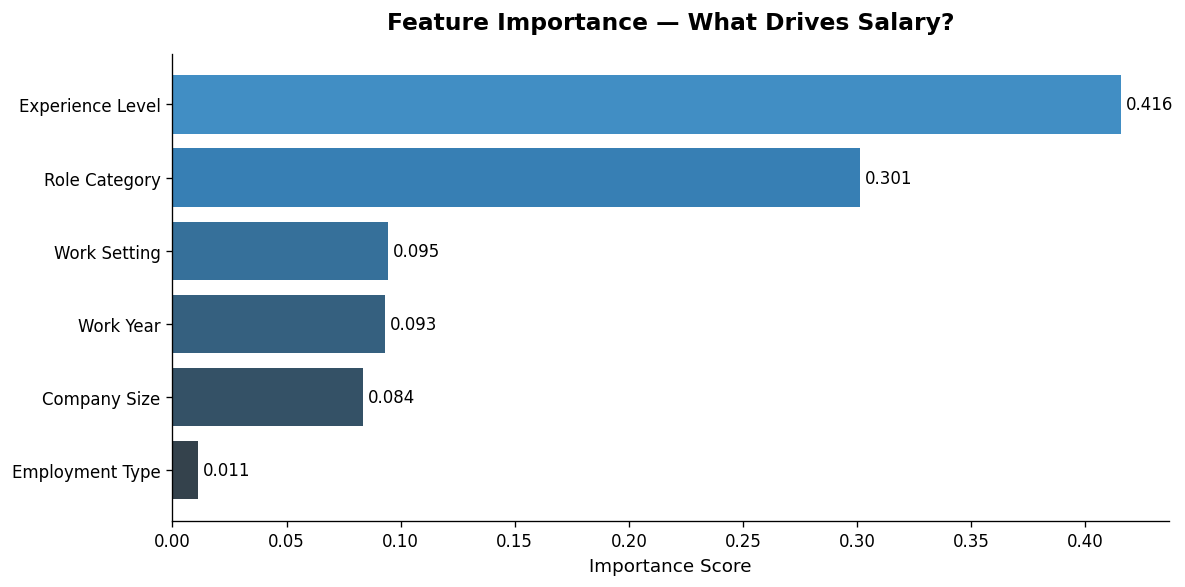


📊 KEY INSIGHT:
→ 'Experience Level' is the strongest predictor of salary
→ This confirms that role type and experience matter
   more than company size or work setting


In [54]:
# ============================================================
# CELL 40: Feature Importance — What Drives Salary?
# ============================================================

importance_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Clean feature names for display
importance_df['Feature'] = (importance_df['Feature']
    .str.replace('_encoded', '')
    .str.replace('_', ' ')
    .str.title())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=PALETTE_BLUE[::-1][:len(importance_df)]
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Feature Importance — What Drives Salary?',
             pad=15, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/chart_09_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

top_feature = importance_df.iloc[-1]['Feature']
print(f"\n📊 KEY INSIGHT:")
print(f"→ '{top_feature}' is the strongest predictor of salary")
print(f"→ This confirms that role type and experience matter")
print(f"   more than company size or work setting")

In [55]:
# ============================================================
# CELL 41 (FIXED): Salary Predictor Function
# ============================================================

def predict_salary(role, experience, work_setting,
                   company_size, year=2024):
    """
    Predict salary given job characteristics.

    Valid roles:      'Data Analyst', 'Data Scientist',
                      'Data Engineer', 'ML Engineer',
                      'AI Engineer', 'BI Developer', etc.
    Valid experience: 'Entry-level', 'Mid-level',
                      'Senior', 'Executive'
    Valid settings:   'Remote', 'Hybrid', 'In-person'
    Valid sizes:      'Small', 'Medium', 'Large'
    """
    try:
        input_data = {
            'role_category_encoded':
                encoders['role_category'].transform([role])[0],
            'experience_level_encoded':
                encoders['experience_level'].transform([experience])[0],
            'employment_type_encoded':
                encoders['employment_type'].transform(['Full-time'])[0],
            'work_setting_encoded':
                encoders['work_setting'].transform([work_setting])[0],
            'company_size_encoded':
                encoders['company_size'].transform([company_size])[0],
            'work_year': year
        }

        X_input  = pd.DataFrame([input_data])
        pred_usd = rf_model.predict(X_input)[0]
        pred_inr = pred_usd * 83

        print(f"\n{'='*50}")
        print(f"  SALARY PREDICTION RESULT")
        print(f"{'='*50}")
        print(f"  Role:         {role}")
        print(f"  Experience:   {experience}")
        print(f"  Work Setting: {work_setting}")
        print(f"  Company Size: {company_size}")
        print(f"  Year:         {year}")
        print(f"{'─'*50}")
        print(f"  Predicted Salary: ${pred_usd:,.0f} USD")
        print(f"  Predicted Salary: ₹{pred_inr:,.0f} INR")
        print(f"{'='*50}")
        return pred_usd

    except ValueError as e:
        print(f"❌ Invalid input: {e}")
        print(f"\nValid roles:")
        for r in encoders['role_category'].classes_:
            print(f"   → {r}")
        print(f"\nValid experience levels:")
        for e in encoders['experience_level'].classes_:
            print(f"   → {e}")

# ── Test 1: Entry-level Data Analyst, Remote, Medium ──
print("TEST 1 — Entry-level Data Analyst | Remote | Medium company:")
predict_salary('Data Analyst', 'Entry-level', 'Remote', 'Medium')

# ── Test 2: Senior ML Engineer, Hybrid, Large ──
print("\nTEST 2 — Senior ML Engineer | Hybrid | Large company:")
predict_salary('ML Engineer', 'Senior', 'Hybrid', 'Large')

# ── Test 3: Mid-level Data Scientist, In-person, Small ──
print("\nTEST 3 — Mid-level Data Scientist | In-person | Small company:")
predict_salary('Data Scientist', 'Mid-level', 'In-person', 'Small')

TEST 1 — Entry-level Data Analyst | Remote | Medium company:

  SALARY PREDICTION RESULT
  Role:         Data Analyst
  Experience:   Entry-level
  Work Setting: Remote
  Company Size: Medium
  Year:         2024
──────────────────────────────────────────────────
  Predicted Salary: $79,784 USD
  Predicted Salary: ₹6,622,041 INR

TEST 2 — Senior ML Engineer | Hybrid | Large company:

  SALARY PREDICTION RESULT
  Role:         ML Engineer
  Experience:   Senior
  Work Setting: Hybrid
  Company Size: Large
  Year:         2024
──────────────────────────────────────────────────
  Predicted Salary: $77,529 USD
  Predicted Salary: ₹6,434,889 INR

TEST 3 — Mid-level Data Scientist | In-person | Small company:

  SALARY PREDICTION RESULT
  Role:         Data Scientist
  Experience:   Mid-level
  Work Setting: In-person
  Company Size: Small
  Year:         2024
──────────────────────────────────────────────────
  Predicted Salary: $101,024 USD
  Predicted Salary: ₹8,385,030 INR


np.float64(101024.46233438143)

In [58]:
# ============================================================
# CELL 44 (REPLACEMENT): Download Files Individually
# ============================================================

from google.colab import files

# Download notebook (most important)
# In Colab: File → Download → Download .ipynb

# Download all charts one by one
import os
charts = sorted([f for f in os.listdir('/content/')
                 if f.startswith('chart_')])

print("Charts to download:")
for c in charts:
    print(f"  → {c}")

print("\nDownloading charts now...")
for chart in charts:
    files.download(f'/content/{chart}')

print("\n✅ All charts downloading")

Charts to download:
  → chart_01_role_demand.png
  → chart_02_salary_by_role.png
  → chart_03_experience_salary.png
  → chart_04_salary_trends.png
  → chart_05_remote_trends.png
  → chart_06_top_countries.png
  → chart_07_india_spotlight.png
  → chart_08_company_size.png
  → chart_09_feature_importance.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All charts downloading


In [61]:
import os
os.makedirs('/content/reports/', exist_ok=True)

with open('/content/reports/insight_report.txt', 'w') as f:
    f.write("Report placeholder - see notebook for full findings")

from google.colab import files
files.download('/content/reports/insight_report.txt')
print("✅ Done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done
